# Diagnosing Poor-Performing States

States where the crop mask **fails to improve** (or actively degrades) the pooled
GCVI-yield correlation. The goal is to see *what the underlying district data looks
like* in these states, rather than only their summary Δr.

**Definitions** (see `gsv_preds_exploration.ipynb`)
- **pooled r** — one Pearson over all district-years in a state
- **Δr** — `r_masked − r_raw`, both pooled
- **district r** — Pearson within one district across its ~12 years

A state can have positive pooled Δr while every district individually gets worse,
and vice versa — so both views are plotted here.


In [1]:
import os, sys, glob, re
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import nbformat

ROOT = '../..'
OUT  = f'{ROOT}/outputs'
os.makedirs(OUT, exist_ok=True)

# Reuse the canonical config (REGIONS, REGION_MASKS, NAME_FIXES, extract_gcvi,
# load_yield) from the main analysis notebook, so there is one source of truth.
_nb = nbformat.read('gsv_preds_exploration.ipynb', as_version=4)
_src = next(c.source for c in _nb.cells if c.get('id') == 'ee4f17d1')
_src = _src.replace("os.makedirs('outputs', exist_ok=True)", "")
_src = _src.replace("'../../data/", f"'{ROOT}/data/")
CFG = {}
exec(_src, CFG)
REGIONS, REGION_MASKS = CFG['REGIONS'], CFG['REGION_MASKS']
REGION_LABELS = CFG['REGION_LABELS']
extract_gcvi, load_yield = CFG['extract_gcvi'], CFG['load_yield']
print(f"config loaded: {len(REGIONS)} states")

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Configured 30 states.
config loaded: 30 states


## 1. Which states underperform?

Ranked by pooled Δr for the crop mask.

In [2]:
corr = pd.read_csv(f'{OUT}/gcvi_yield_correlation.csv')

rows = []
for k in corr['region'].unique():
    s = corr[corr['region'] == k]
    raw  = s[s['mask'] == 'raw']['r'].values
    crop = s[s['mask'].isin(['crop', 'jordi'])]['r'].values
    if len(raw) == 0 or len(crop) == 0:
        continue
    rows.append({'region_key': k, 'label': REGION_LABELS.get(k, k),
                 'r_raw': raw[0], 'r_crop': crop[0],
                 'delta': crop[0] - raw[0],
                 'n_districts': s[s['mask'] == 'raw']['n_districts'].values[0]})
pooled = pd.DataFrame(rows).sort_values('delta')

# poor = mask does not meaningfully help
POOR = pooled[pooled['delta'] < 0.05]['region_key'].tolist()
print("POOR PERFORMERS (pooled Δr < 0.05):")
print(pooled[pooled['region_key'].isin(POOR)]
      [['label', 'r_raw', 'r_crop', 'delta', 'n_districts']].round(3).to_string(index=False))
print(f"\nbest for contrast:")
print(pooled.tail(3)[['label','r_raw','r_crop','delta']].round(3).to_string(index=False))

POOR PERFORMERS (pooled Δr < 0.05):
      label  r_raw  r_crop  delta  n_districts
 Chandigarh -0.103  -0.185 -0.082            1
Maharashtra  0.437   0.373 -0.064           28
    Tripura -0.193  -0.251 -0.058            8
     Punjab  0.628   0.583 -0.045           22
      Bihar  0.480   0.506  0.026           37
      Assam  0.233   0.261  0.028           33

best for contrast:
    label  r_raw  r_crop  delta
Rajasthan -0.234   0.845  1.079
 Nagaland -0.294   0.950  1.244
  Manipur -0.711   0.617  1.328


## 2. Build the district-year panel for each poor state

For every district: mean peak GCVI under the raw and masked rasters, joined to yield.
`gcvi_masked == 0` means the crop mask found no pixels in that district.

In [3]:
def panel(region_key):
    """district x year panel with raw and masked GCVI + yield for one state."""
    cfg  = REGIONS[region_key]
    y    = load_yield(cfg['state_name'])
    mask = REGION_MASKS[region_key][2]           # 'crop' or 'jordi'
    raw  = extract_gcvi(region_key, 'raw').rename(columns={'gcvi_mean': 'gcvi_raw'})
    msk  = extract_gcvi(region_key, mask).rename(columns={'gcvi_mean': 'gcvi_mask'})
    df = (raw.merge(msk, on=['district', 'year'])
             .merge(y,   on=['district', 'year'], how='inner').dropna())
    # same zero-fill rule the main notebook uses
    df.loc[df['gcvi_mask'] == 0, 'yield_zero'] = 0
    df['region_key'] = region_key
    return df

panels = {}
for k in POOR:
    try:
        panels[k] = panel(k)
        print(f"  {k:<14} {len(panels[k]):>4} district-years, "
              f"{panels[k]['district'].nunique():>3} districts, "
              f"{(panels[k]['gcvi_mask']==0).mean()*100:>5.1f}% zero-mask rows")
    except Exception as e:
        print(f"  {k:<14} FAILED: {type(e).__name__}: {e}")

  chandigarh       12 district-years,   1 districts,   0.0% zero-mask rows


  maharashtra     289 district-years,  28 districts,  20.8% zero-mask rows


  tripura          96 district-years,   8 districts,   0.0% zero-mask rows


  punjab          264 district-years,  22 districts,   0.0% zero-mask rows


  bihar           314 district-years,  37 districts,   0.0% zero-mask rows


  assam           352 district-years,  33 districts,   0.0% zero-mask rows


## 3. District-level r — raw vs masked

**This is the main diagnostic.** Each point is one district: its correlation across
~12 years using raw GCVI (x) vs masked GCVI (y). Points **below the 1:1 line** are
districts the mask made *worse*.

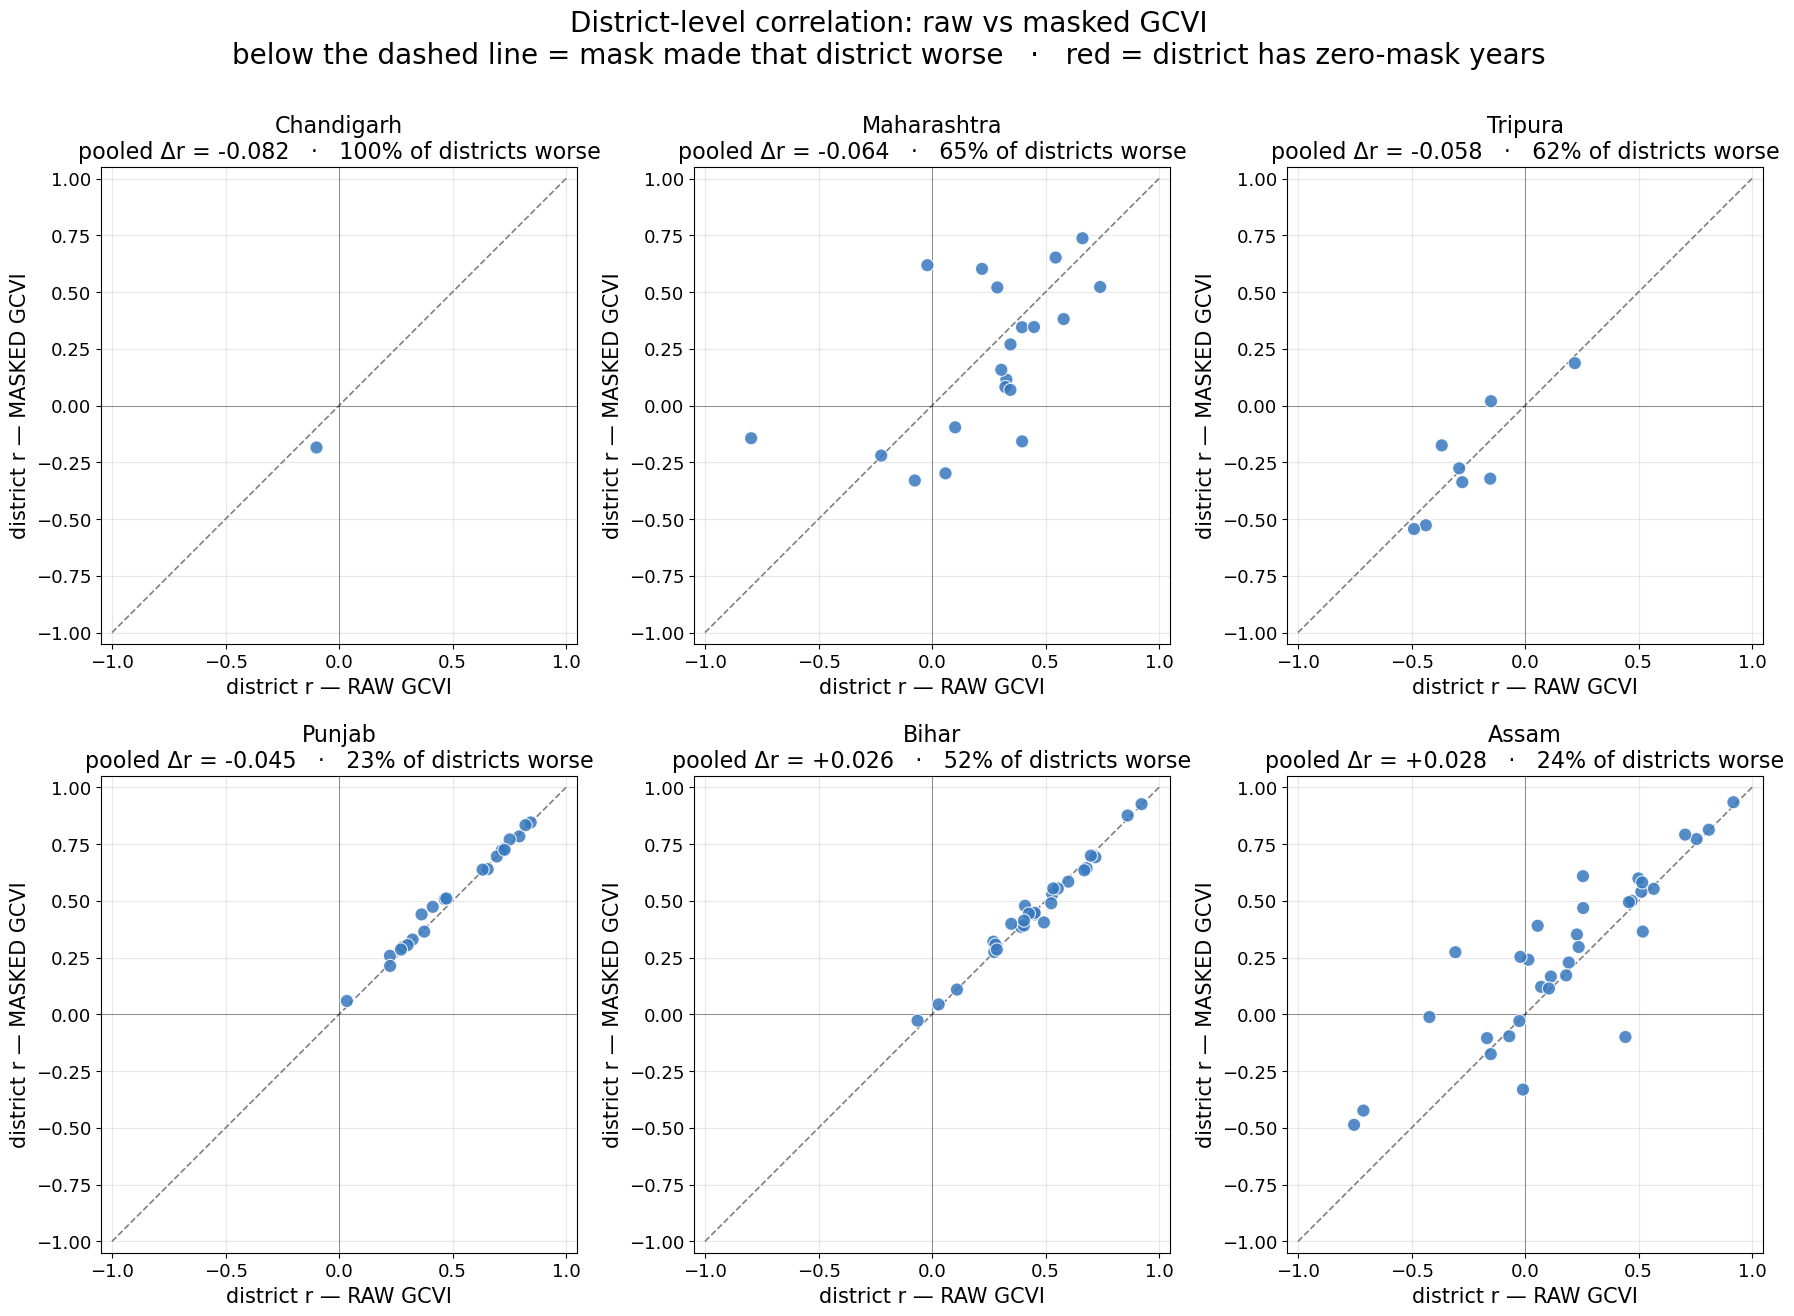

plotted 6 states in a 2x3 grid


In [4]:
import math

plt.rcParams.update({
    'font.size': 14, 'axes.titlesize': 16, 'axes.labelsize': 15,
    'xtick.labelsize': 13, 'ytick.labelsize': 13,
    'legend.fontsize': 13, 'figure.titlesize': 20,
})

def district_r(df):
    out = []
    for d, g in df.groupby('district'):
        if len(g) < 5:
            continue
        ok = lambda a, b: g[a].nunique() > 1 and g[b].nunique() > 1
        r_raw  = stats.pearsonr(g['gcvi_raw'],  g['yield_kg_ha'])[0] if ok('gcvi_raw','yield_kg_ha')  else np.nan
        r_mask = stats.pearsonr(g['gcvi_mask'], g['yield_kg_ha'])[0] if ok('gcvi_mask','yield_kg_ha') else np.nan
        out.append({'district': d, 'n_years': len(g),
                    'r_raw': r_raw, 'r_mask': r_mask,
                    'delta': r_mask - r_raw,
                    'zero_mask_frac': (g['gcvi_mask'] == 0).mean()})
    return pd.DataFrame(out)

dr = {k: district_r(v) for k, v in panels.items()}
d_by_state = dr

n     = len(dr)
ncols = math.ceil(n / 2)
nrows = 2
fig, axes = plt.subplots(nrows, ncols, figsize=(6.0 * ncols, 6.6 * nrows), squeeze=False)

# axes.flat walks BOTH rows — zip(axes[0], ...) would only fill the first row
for ax, (k, d) in zip(axes.flat, dr.items()):
    v   = d.dropna(subset=['r_raw', 'r_mask'])
    col = np.where(v['zero_mask_frac'] > 0, '#d62728', '#3778bf')
    ax.scatter(v['r_raw'], v['r_mask'], s=90, c=col,
               edgecolors='white', linewidths=0.8, alpha=0.85, zorder=3)
    ax.plot([-1, 1], [-1, 1], ls='--', c='grey', lw=1.2, zorder=2)
    ax.axhline(0, c='black', lw=0.7, alpha=0.4)
    ax.axvline(0, c='black', lw=0.7, alpha=0.4)

    worse = (v['delta'] < 0).mean() * 100
    pr    = pooled[pooled.region_key == k]
    ax.set_title(f"{REGION_LABELS.get(k, k)}\n"
                 f"pooled Δr = {pr['delta'].values[0]:+.3f}   ·   "
                 f"{worse:.0f}% of districts worse")
    ax.set_xlabel('district r — RAW GCVI')
    ax.set_ylabel('district r — MASKED GCVI')
    ax.set_xlim(-1.05, 1.05); ax.set_ylim(-1.05, 1.05)
    ax.set_aspect('equal'); ax.grid(alpha=0.3)

# blank any unused panels when n is odd
for ax in list(axes.flat)[n:]:
    ax.axis('off')

fig.suptitle('District-level correlation: raw vs masked GCVI\n'
             'below the dashed line = mask made that district worse   ·   '
             'red = district has zero-mask years', y=1.0)
plt.tight_layout()
plt.savefig(f'{OUT}/poor_states_district_r.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"plotted {n} states in a {nrows}x{ncols} grid")

## 4. What the pooled correlation actually sees

The pooled r is computed over this cloud — all districts and years at once. Colouring
by district shows how much of the pooled relationship is *between* districts rather
than *within* them.

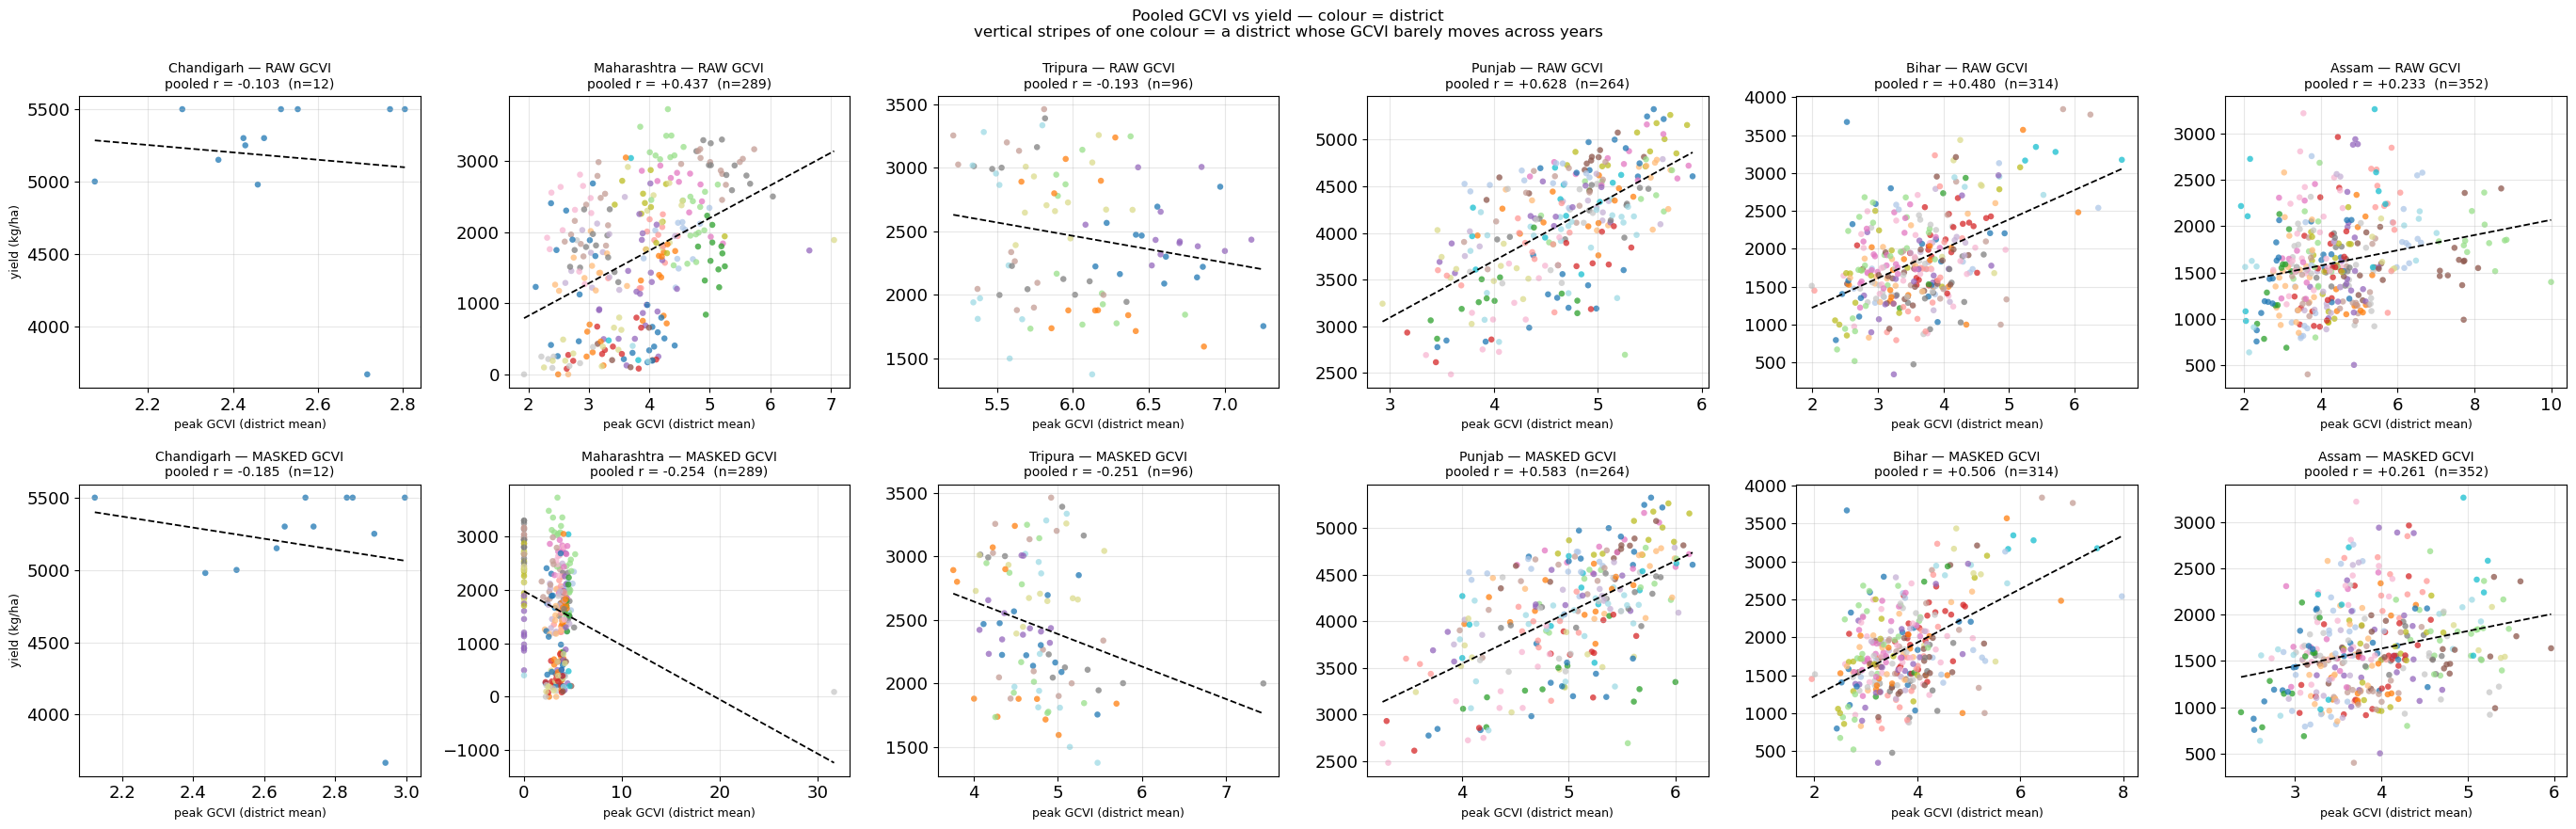

In [5]:
n = len(panels)
fig, axes = plt.subplots(2, n, figsize=(4.6 * n, 9), squeeze=False)
for j, (k, df) in enumerate(panels.items()):
    for i, (gc, lab) in enumerate([('gcvi_raw', 'RAW GCVI'), ('gcvi_mask', 'MASKED GCVI')]):
        ax = axes[i, j]
        codes = pd.factorize(df['district'])[0]
        ax.scatter(df[gc], df['yield_kg_ha'], c=codes, cmap='tab20',
                   s=22, alpha=0.75, edgecolors='none')
        v = df[[gc, 'yield_kg_ha']].dropna()
        if v[gc].nunique() > 1:
            r, p = stats.pearsonr(v[gc], v['yield_kg_ha'])
            b, a_ = np.polyfit(v[gc], v['yield_kg_ha'], 1)
            xs = np.linspace(v[gc].min(), v[gc].max(), 50)
            ax.plot(xs, b * xs + a_, c='black', lw=1.3, ls='--')
            ax.set_title(f"{REGION_LABELS.get(k,k)} — {lab}\n"
                         f"pooled r = {r:+.3f}  (n={len(v)})", fontsize=10)
        ax.set_xlabel('peak GCVI (district mean)', fontsize=9)
        if j == 0:
            ax.set_ylabel('yield (kg/ha)', fontsize=9)
        ax.grid(alpha=0.3)

fig.suptitle('Pooled GCVI vs yield — colour = district\n'
             'vertical stripes of one colour = a district whose GCVI barely moves across years',
             fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUT}/poor_states_pooled_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Diagnostics table

In [6]:
diag = []
for k, df in panels.items():
    d = dr[k].dropna(subset=['r_raw', 'r_mask'])
    pr = pooled[pooled.region_key == k].iloc[0]
    # how much of the pooled variance is BETWEEN districts?
    tot = df['yield_kg_ha'].var()
    within = df.groupby('district')['yield_kg_ha'].var().mean()
    diag.append({
        'state': REGION_LABELS.get(k, k),
        'pooled_dr': pr['delta'],
        'district_dr_mean': d['delta'].mean(),
        'pct_districts_worse': 100 * (d['delta'] < 0).mean(),
        'pct_rows_zero_mask': 100 * (df['gcvi_mask'] == 0).mean(),
        'gcvi_mask_cv': df['gcvi_mask'].std() / df['gcvi_mask'].mean() if df['gcvi_mask'].mean() else np.nan,
        'gcvi_raw_cv':  df['gcvi_raw'].std()  / df['gcvi_raw'].mean(),
        'between_district_var_share': 1 - within / tot if tot else np.nan,
    })
D = pd.DataFrame(diag).sort_values('pooled_dr')
D.to_csv(f'{OUT}/poor_states_diagnostics.csv', index=False)
print(D.round(3).to_string(index=False))
print(f"\nwrote {OUT}/poor_states_diagnostics.csv")

      state  pooled_dr  district_dr_mean  pct_districts_worse  pct_rows_zero_mask  gcvi_mask_cv  gcvi_raw_cv  between_district_var_share
 Chandigarh     -0.082            -0.082              100.000               0.000         0.092        0.084                       0.000
Maharashtra     -0.064            -0.040               65.000              20.761         0.777        0.231                       0.652
    Tripura     -0.058            -0.004               62.500               0.000         0.108        0.079                       0.011
     Punjab     -0.045             0.014               22.727               0.000         0.128        0.134                       0.689
      Bihar      0.026             0.001               51.852               0.000         0.228        0.206                       0.001
      Assam      0.028             0.079               24.242               0.000         0.174        0.311                       0.174

wrote ../../outputs/poor_states_diagnost

## 6. Map quality — does it explain the failures?

Brings in `data/statewise_report_summary.csv`: per-state Random-Forest classifier
metrics for the crop map. The key columns are **`f1_Rice`** (how well the classifier
identifies rice), **`n_points_class_2`** (how many rice training points the state had),
and **`crop_2_Rice_R`** (Clark-Evans R — spatial clustering of those points; <1 means
clustered, so less representative).

In [7]:
# ── map quality metrics from the RF classifier report ─────────────────────
rep = pd.read_csv(f'{ROOT}/data/statewise_report_summary.csv')

RF2KEY = {'Madhya Pradesh':'mp','Uttar Pradesh':'up','West Bengal':'wb',
          'Jammu and Kashmir':'jammu_kashmir','NCT of Delhi':'delhi',
          'Daman and Diu':'dadra_nagar_haveli'}
rep['region_key'] = rep['state_rf'].map(lambda s: RF2KEY.get(s, s.lower().replace(' ', '_')))

QCOLS = ['f1_Rice','precision_Rice','recall_Rice','n_points_class_2',
         'crop_2_Rice_R','weighted_agreement_Rice','f1_macro','n_train_points']
Q = rep[['region_key','state_rf'] + [c for c in QCOLS if c in rep.columns]]

qual = pooled.merge(Q, on='region_key', how='left')
qual['is_poor'] = qual['region_key'].isin(POOR)

print("MAP QUALITY for the poor performers")
print(qual[qual.is_poor][['label','delta','f1_Rice','n_points_class_2',
                          'weighted_agreement_Rice','crop_2_Rice_R']]
      .round(3).to_string(index=False))
print("\nfor contrast, the three strongest states:")
print(qual.nlargest(3,'delta')[['label','delta','f1_Rice','n_points_class_2',
                                'weighted_agreement_Rice','crop_2_Rice_R']]
      .round(3).to_string(index=False))

print(f"\n\nCorrelation of map-quality metrics with pooled Δr  (all states)")
print(f"{'metric':<26}{'r':>8}{'p':>9}{'n':>5}")
print('-' * 50)
for c in [c for c in QCOLS if c in qual.columns]:
    v = qual[[c,'delta']].dropna()
    if len(v) < 5 or v[c].std() == 0:
        continue
    r, p = stats.pearsonr(v[c], v['delta'])
    print(f"{c:<26}{r:>8.2f}{p:>9.3f}{'*' if p<0.05 else ' '}{len(v):>4}")

MAP QUALITY for the poor performers
      label  delta  f1_Rice  n_points_class_2  weighted_agreement_Rice  crop_2_Rice_R
 Chandigarh -0.082      NaN               0.0                    0.157            NaN
Maharashtra -0.064    0.857              69.0                    0.270          0.089
    Tripura -0.058    0.000               0.0                    0.935            NaN
     Punjab -0.045    0.813            1396.0                    0.522          0.141
      Bihar  0.026    0.854            4124.0                    0.562          0.202
      Assam  0.028    0.953             688.0                    0.841          0.126

for contrast, the three strongest states:
    label  delta  f1_Rice  n_points_class_2  weighted_agreement_Rice  crop_2_Rice_R
  Manipur  1.328      NaN               NaN                      NaN            NaN
 Nagaland  1.244      NaN               NaN                      NaN            NaN
Rajasthan  1.079      0.0              29.0                    0.23

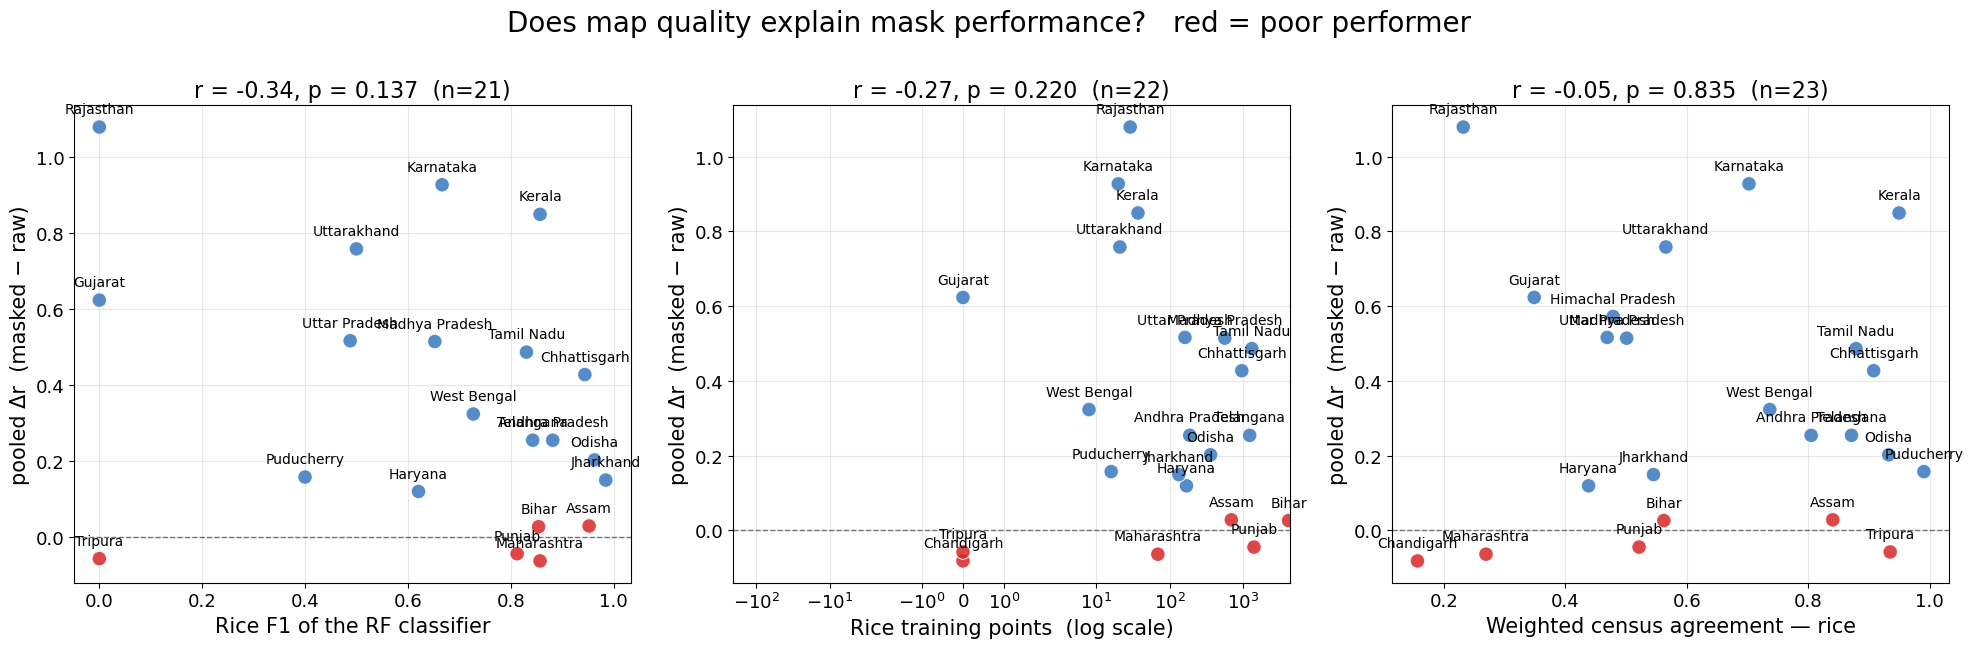

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6.5))
PAIRS = [('f1_Rice', 'Rice F1 of the RF classifier'),
         ('n_points_class_2', 'Rice training points  (log scale)'),
         ('weighted_agreement_Rice', 'Weighted census agreement — rice')]

for ax, (c, lab) in zip(axes, PAIRS):
    v = qual[[c, 'delta', 'label', 'is_poor']].dropna()
    col = np.where(v['is_poor'], '#d62728', '#3778bf')
    ax.scatter(v[c], v['delta'], s=110, c=col, edgecolors='white',
               linewidths=0.8, alpha=0.85, zorder=3)
    for _, r_ in v.iterrows():
        ax.annotate(r_['label'], (r_[c], r_['delta']), fontsize=10,
                    textcoords='offset points', xytext=(0, 10), ha='center')
    ax.axhline(0, c='black', lw=1.0, ls='--', alpha=0.5)
    if c == 'n_points_class_2':
        ax.set_xscale('symlog')
    rr, pp = stats.pearsonr(v[c], v['delta'])
    ax.set_title(f'r = {rr:+.2f}, p = {pp:.3f}  (n={len(v)})')
    ax.set_xlabel(lab)
    ax.set_ylabel('pooled Δr  (masked − raw)')
    ax.grid(alpha=0.3)

fig.suptitle('Does map quality explain mask performance?   red = poor performer', y=1.0)
plt.tight_layout()
plt.savefig(f'{OUT}/poor_states_map_quality.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Per-district Δr on the map

Where within each state does the mask help or hurt? Grey districts could not be matched
to yield data (see `NAME_FIXES` / GAUL redistricting in the main notebook).

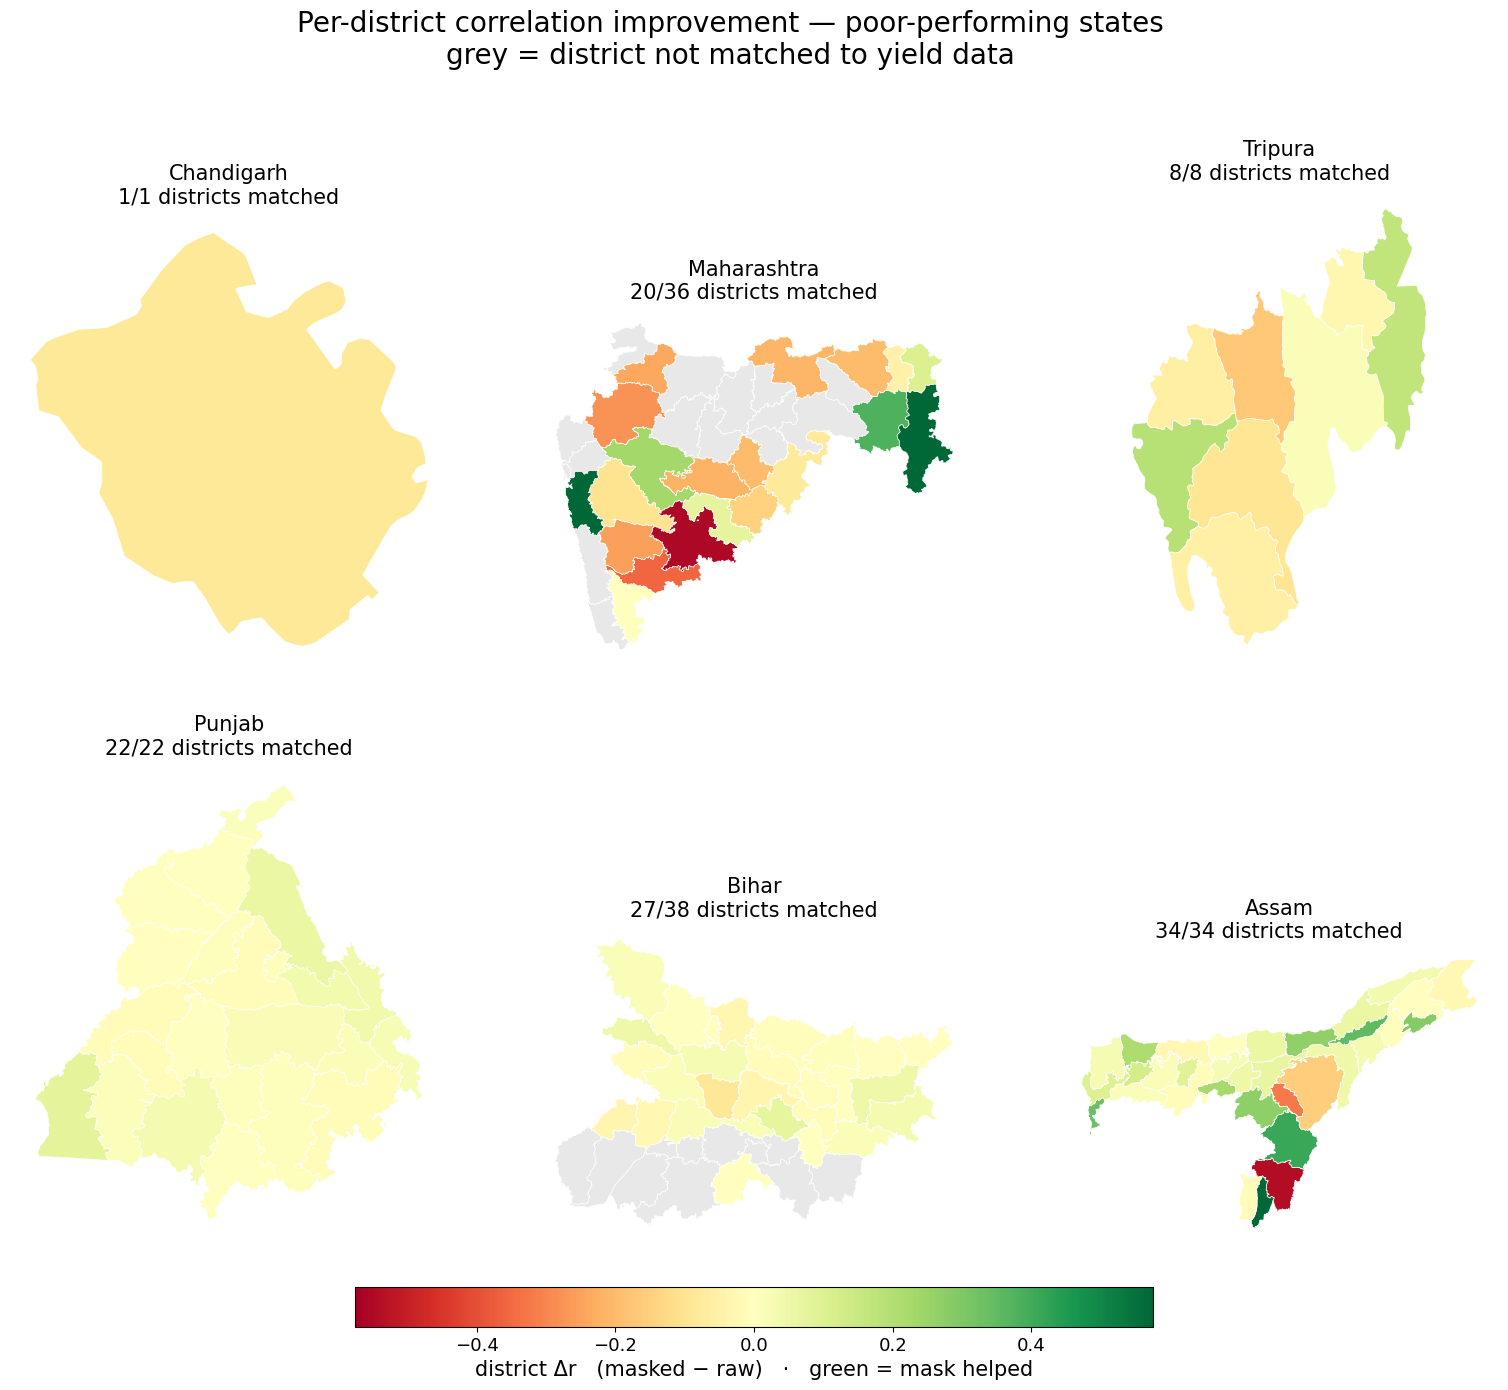

In [9]:
import geopandas as gpd

def load_boundary(path):
    g = gpd.read_file(path).to_crs('EPSG:4326')
    g = g[g.geometry.notna() & ~g.geometry.is_empty]
    if (g.geometry.geom_type == 'GeometryCollection').any():
        g = g.explode(index_parts=False)
        g = g[g.geometry.geom_type.isin(['Polygon', 'MultiPolygon'])]
    g['district'] = (g['gaul2_name'].str.strip().str.title()
                     .str.replace(r'\s+', ' ', regex=True))
    return g

n     = len(dr)
ncols = math.ceil(n / 2)
fig, axes = plt.subplots(2, ncols, figsize=(6.4 * ncols, 7.4 * 2), squeeze=False)

lim = np.nanpercentile(np.abs(pd.concat([d['delta'] for d in dr.values()]).dropna()), 98)

for ax, (k, d) in zip(axes.flat, dr.items()):
    g = load_boundary(REGIONS[k]['shp']).merge(
        d[['district', 'delta', 'zero_mask_frac']], on='district', how='left')
    g.plot(ax=ax, color='#e8e8e8', edgecolor='white', linewidth=0.5)
    sub = g[g['delta'].notna()]
    if len(sub):
        sub.plot(column='delta', ax=ax, cmap='RdYlGn', vmin=-lim, vmax=lim,
                 edgecolor='white', linewidth=0.5)
    matched = g['delta'].notna().sum()
    ax.set_title(f"{REGION_LABELS.get(k,k)}\n"
                 f"{matched}/{len(g)} districts matched", fontsize=15)
    ax.axis('off')

for ax in list(axes.flat)[n:]:
    ax.axis('off')

sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=plt.Normalize(vmin=-lim, vmax=lim))
sm.set_array([])
cb = fig.colorbar(sm, ax=axes, orientation='horizontal', fraction=0.035, pad=0.04)
cb.set_label('district Δr   (masked − raw)   ·   green = mask helped', fontsize=15)

fig.suptitle('Per-district correlation improvement — poor-performing states\n'
             'grey = district not matched to yield data', y=1.0)
plt.savefig(f'{OUT}/poor_states_district_maps.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Training-point coverage

The images show where the RF classifier's labelled points fall. Sparse or spatially
clustered points mean the crop map is extrapolating over most of the state.

no training-point image for: chandigarh, tripura


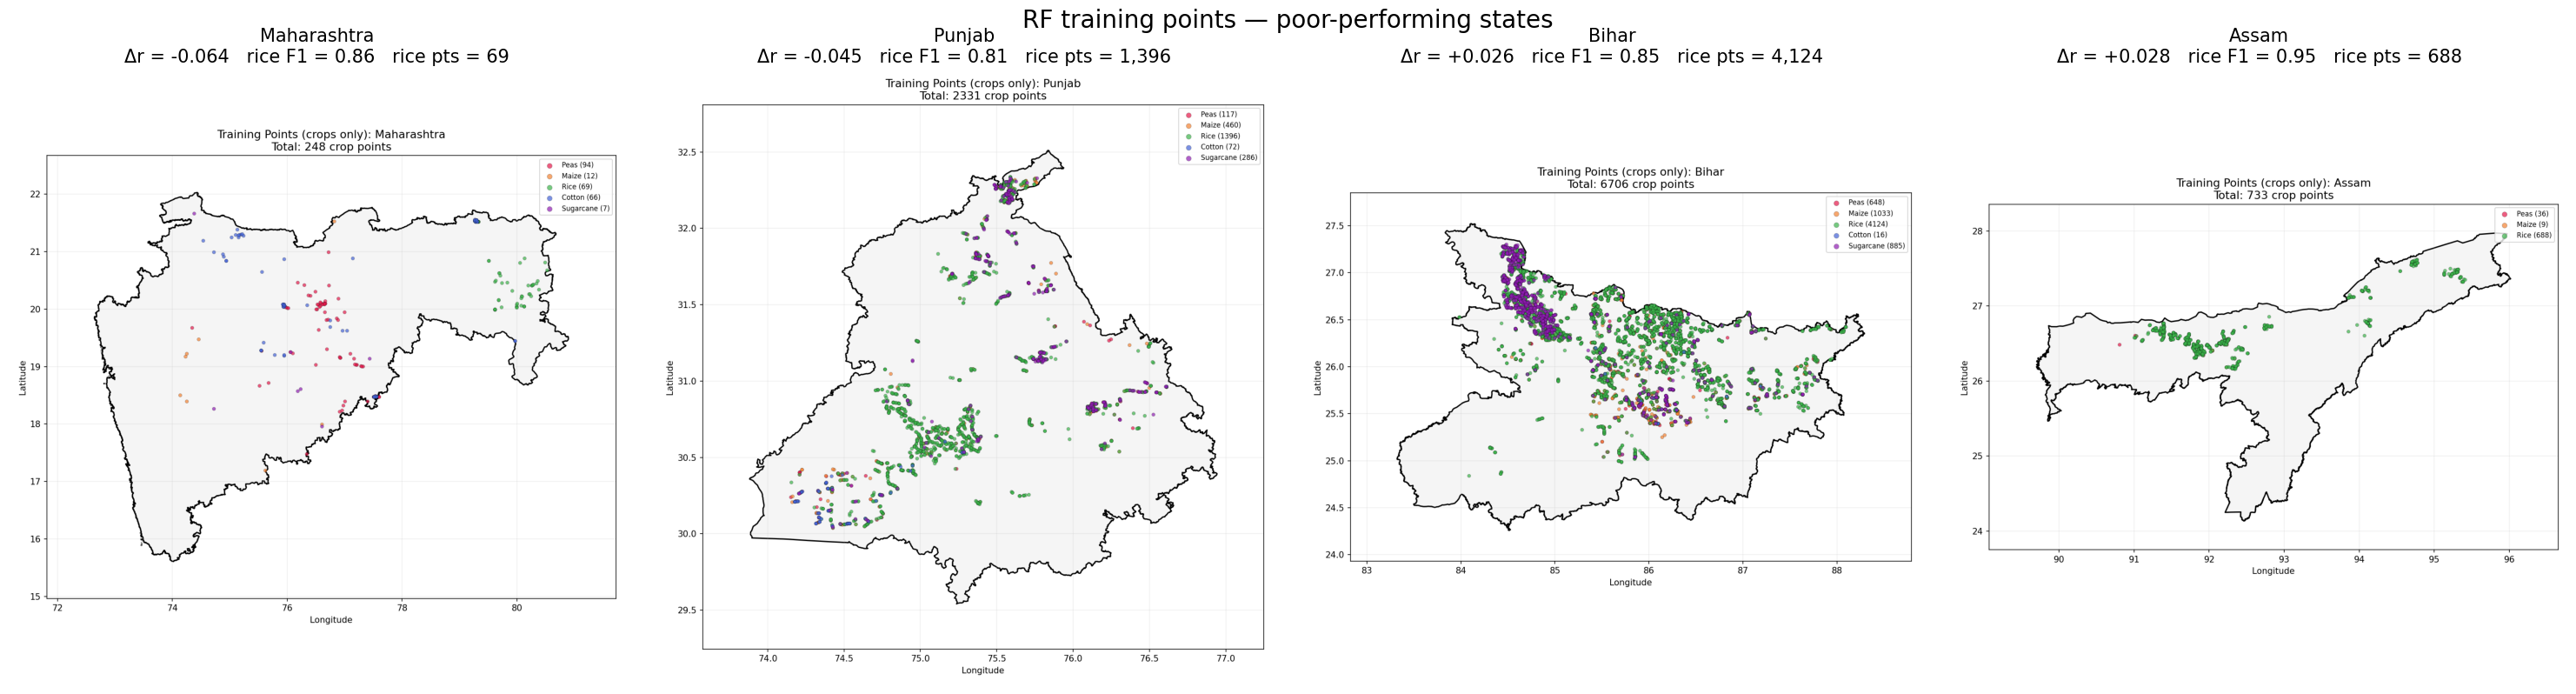

In [10]:
from matplotlib import image as mpimg

IMG_DIR = f'{ROOT}/data/training_points_per_state'
IMG_KEY = {'mp':'madhya_pradesh','up':'uttar_pradesh','wb':'west_bengal'}

have, missing = [], []
for k in POOR:
    f = f"{IMG_DIR}/train_points_{IMG_KEY.get(k, k)}.png"
    (have if os.path.exists(f) else missing).append((k, f))

if missing:
    print("no training-point image for: " + ", ".join(k for k, _ in missing))

if have:
    fig, axes = plt.subplots(1, len(have), figsize=(7.5 * len(have), 8), squeeze=False)
    for ax, (k, f) in zip(axes[0], have):
        ax.imshow(mpimg.imread(f))
        q = qual[qual.region_key == k]
        f1 = q['f1_Rice'].values[0] if len(q) else np.nan
        npt = q['n_points_class_2'].values[0] if len(q) else np.nan
        dl = q['delta'].values[0] if len(q) else np.nan
        ax.set_title(f"{REGION_LABELS.get(k,k)}\n"
                     f"Δr = {dl:+.3f}   rice F1 = {f1:.2f}   rice pts = {npt:,.0f}",
                     fontsize=15)
        ax.axis('off')
    fig.suptitle('RF training points — poor-performing states', y=1.0)
    plt.tight_layout()
    plt.savefig(f'{OUT}/poor_states_training_points.png', dpi=150, bbox_inches='tight')
    plt.show()

## 9. Side by side — training points → masked GCVI → district Δr

Three panels per state, read left to right as a causal chain:

1. **RF training points** (as downloaded) — what the crop map was trained on
2. **GCVI under the rice crop mask** — what the mask actually retains, 2020 kharif
3. **Per-district Δr** — the effect on the GCVI-yield correlation

Panels 2 and 3 are framed to match panel 1: same lon/lat axes with a light grid, ~5%
padding around the state bounds, black district outlines,  so each map
fills its panel. Blank areas in panel 2 are pixels the mask discarded.

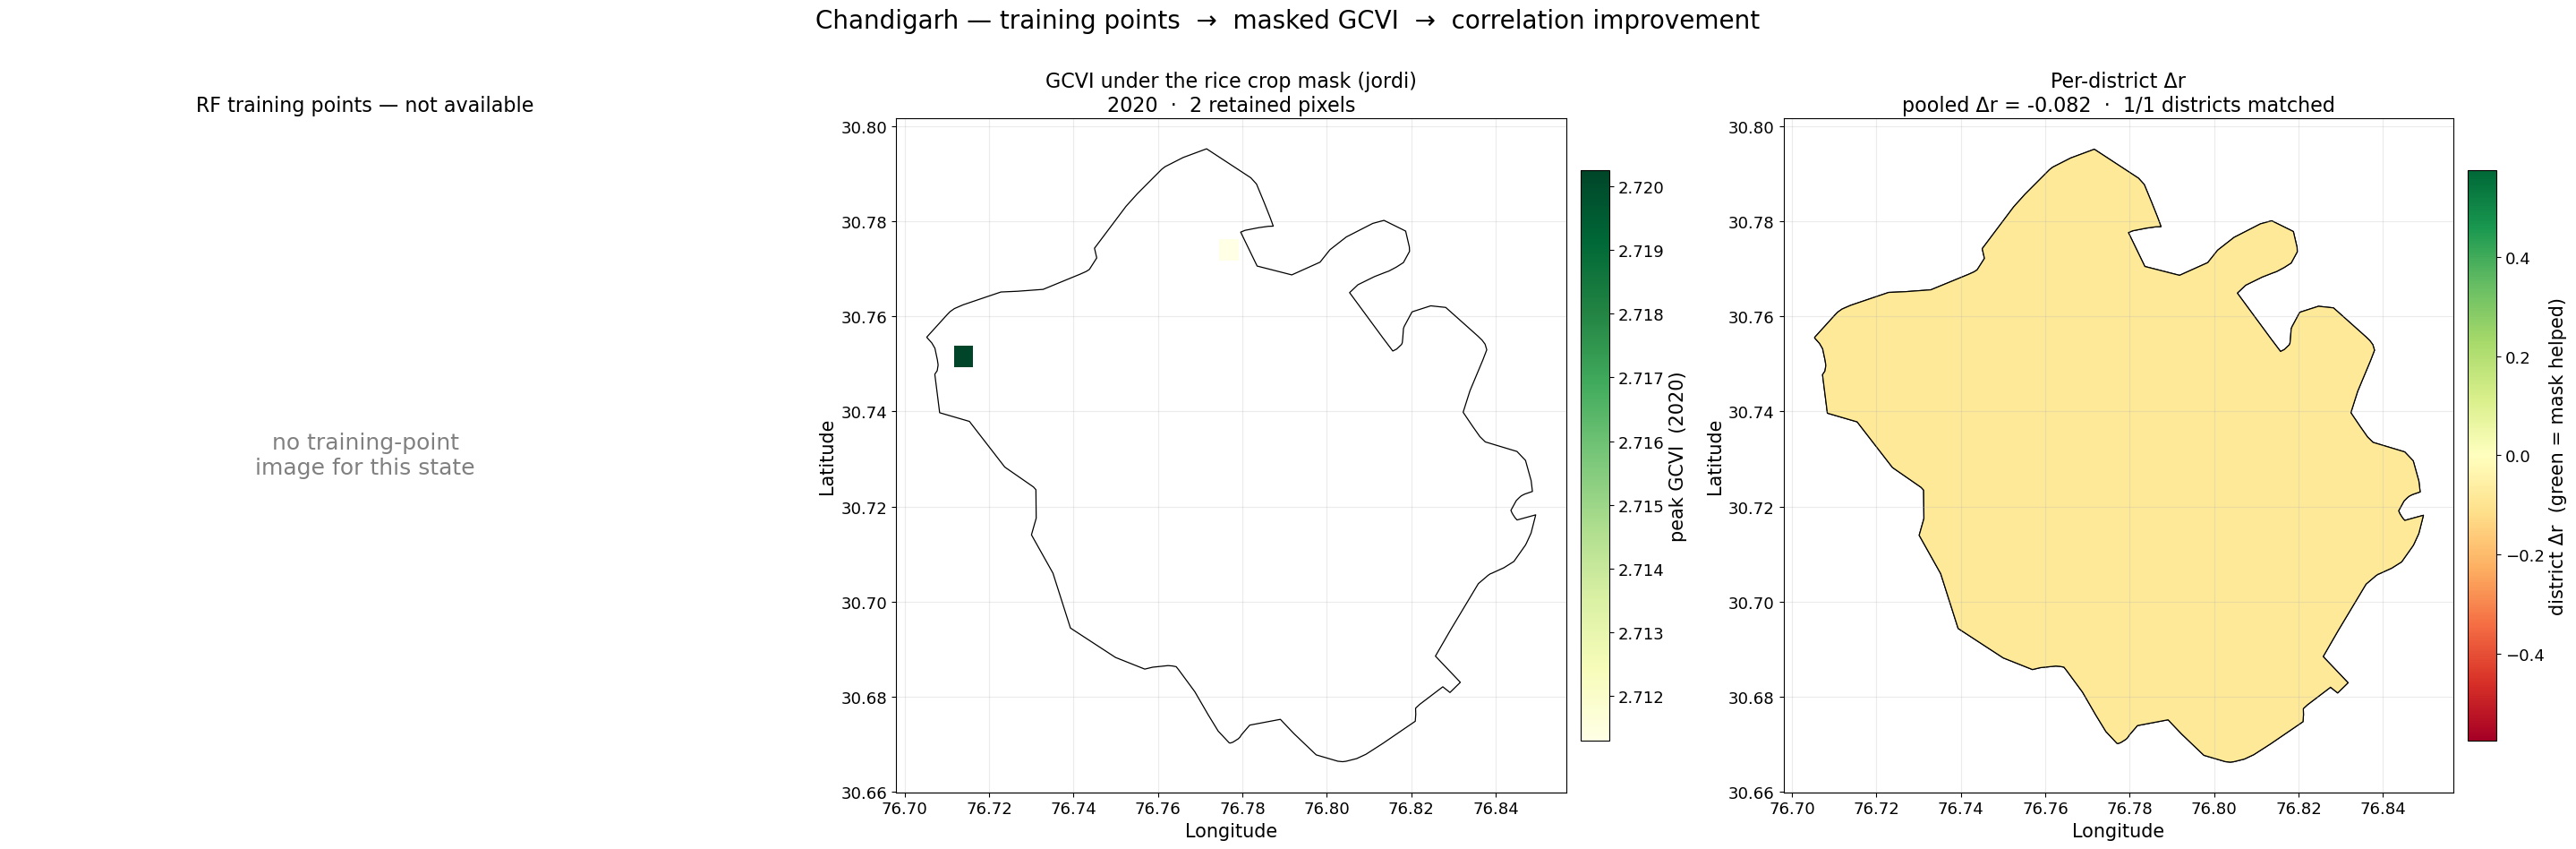

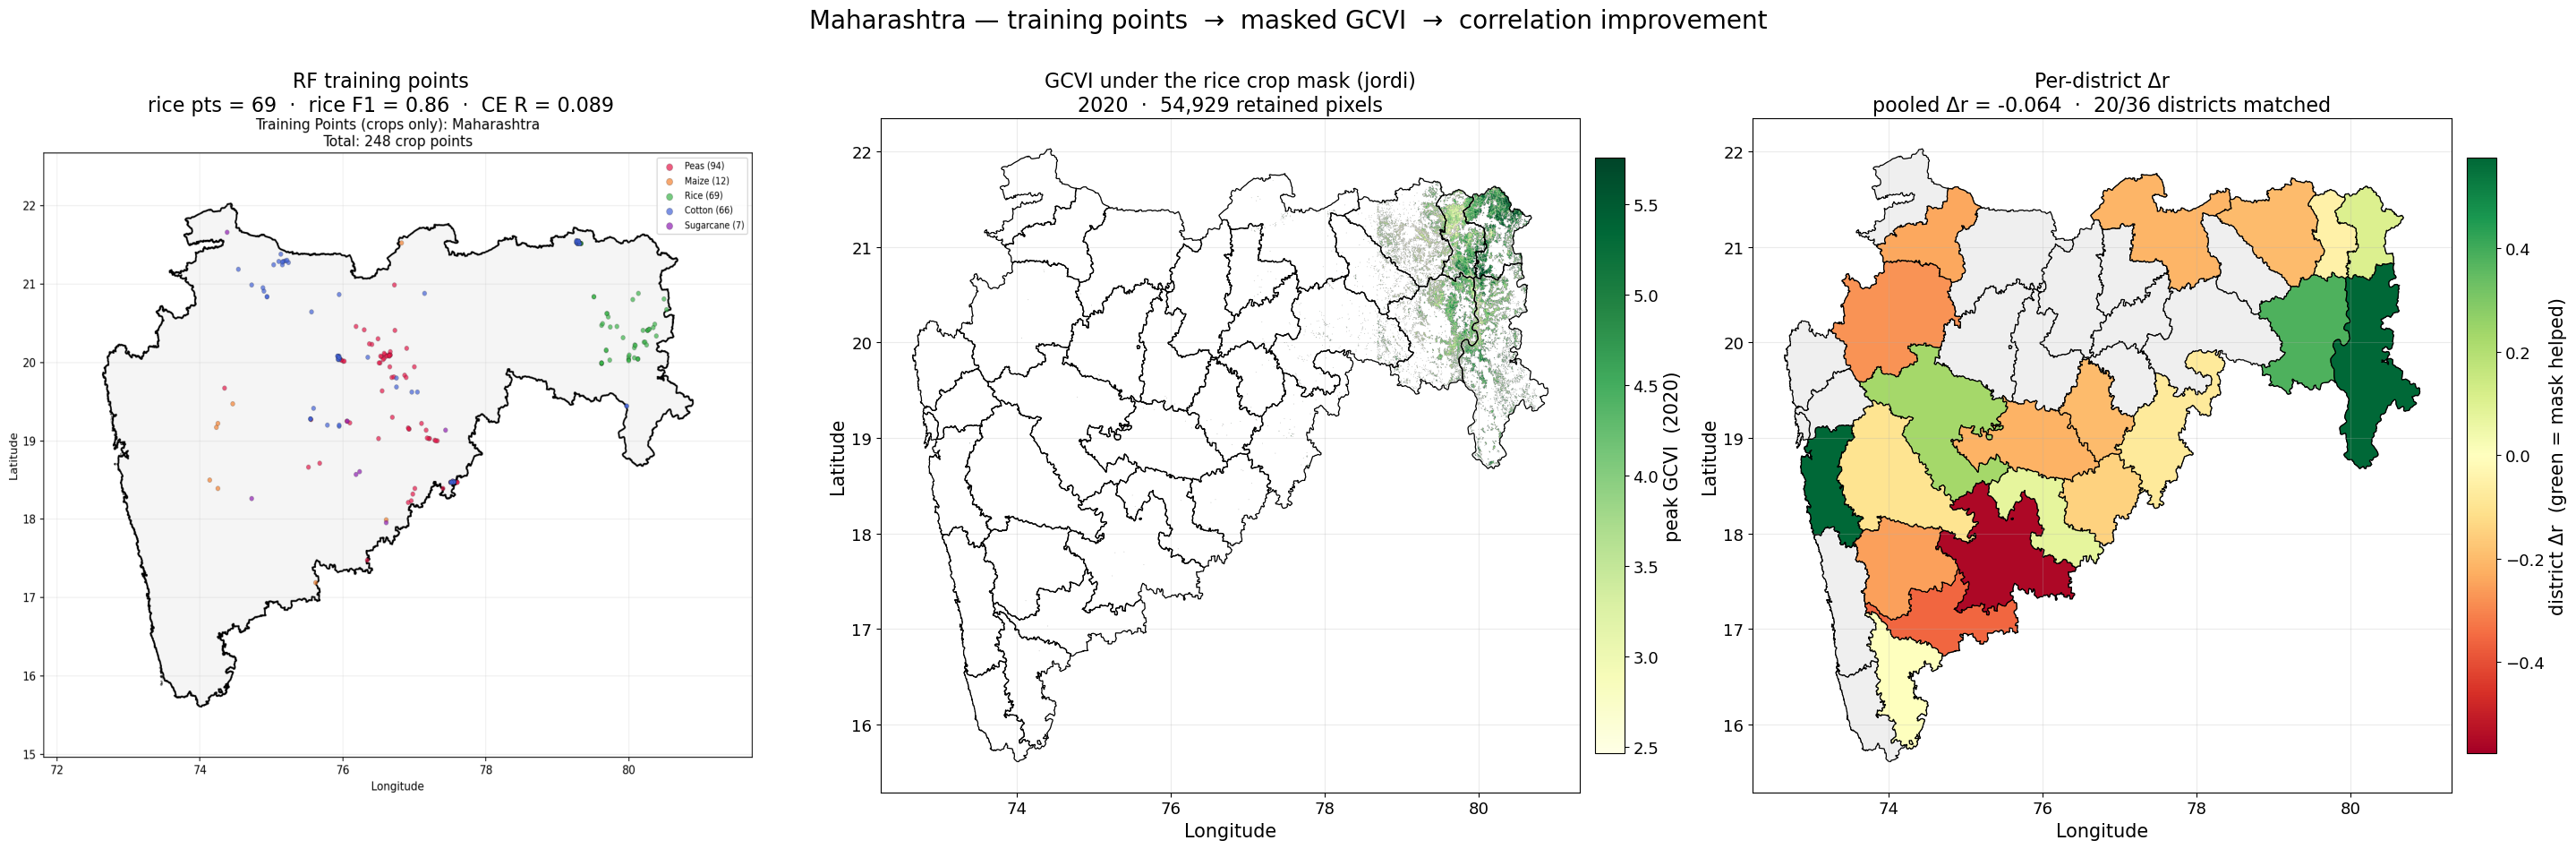

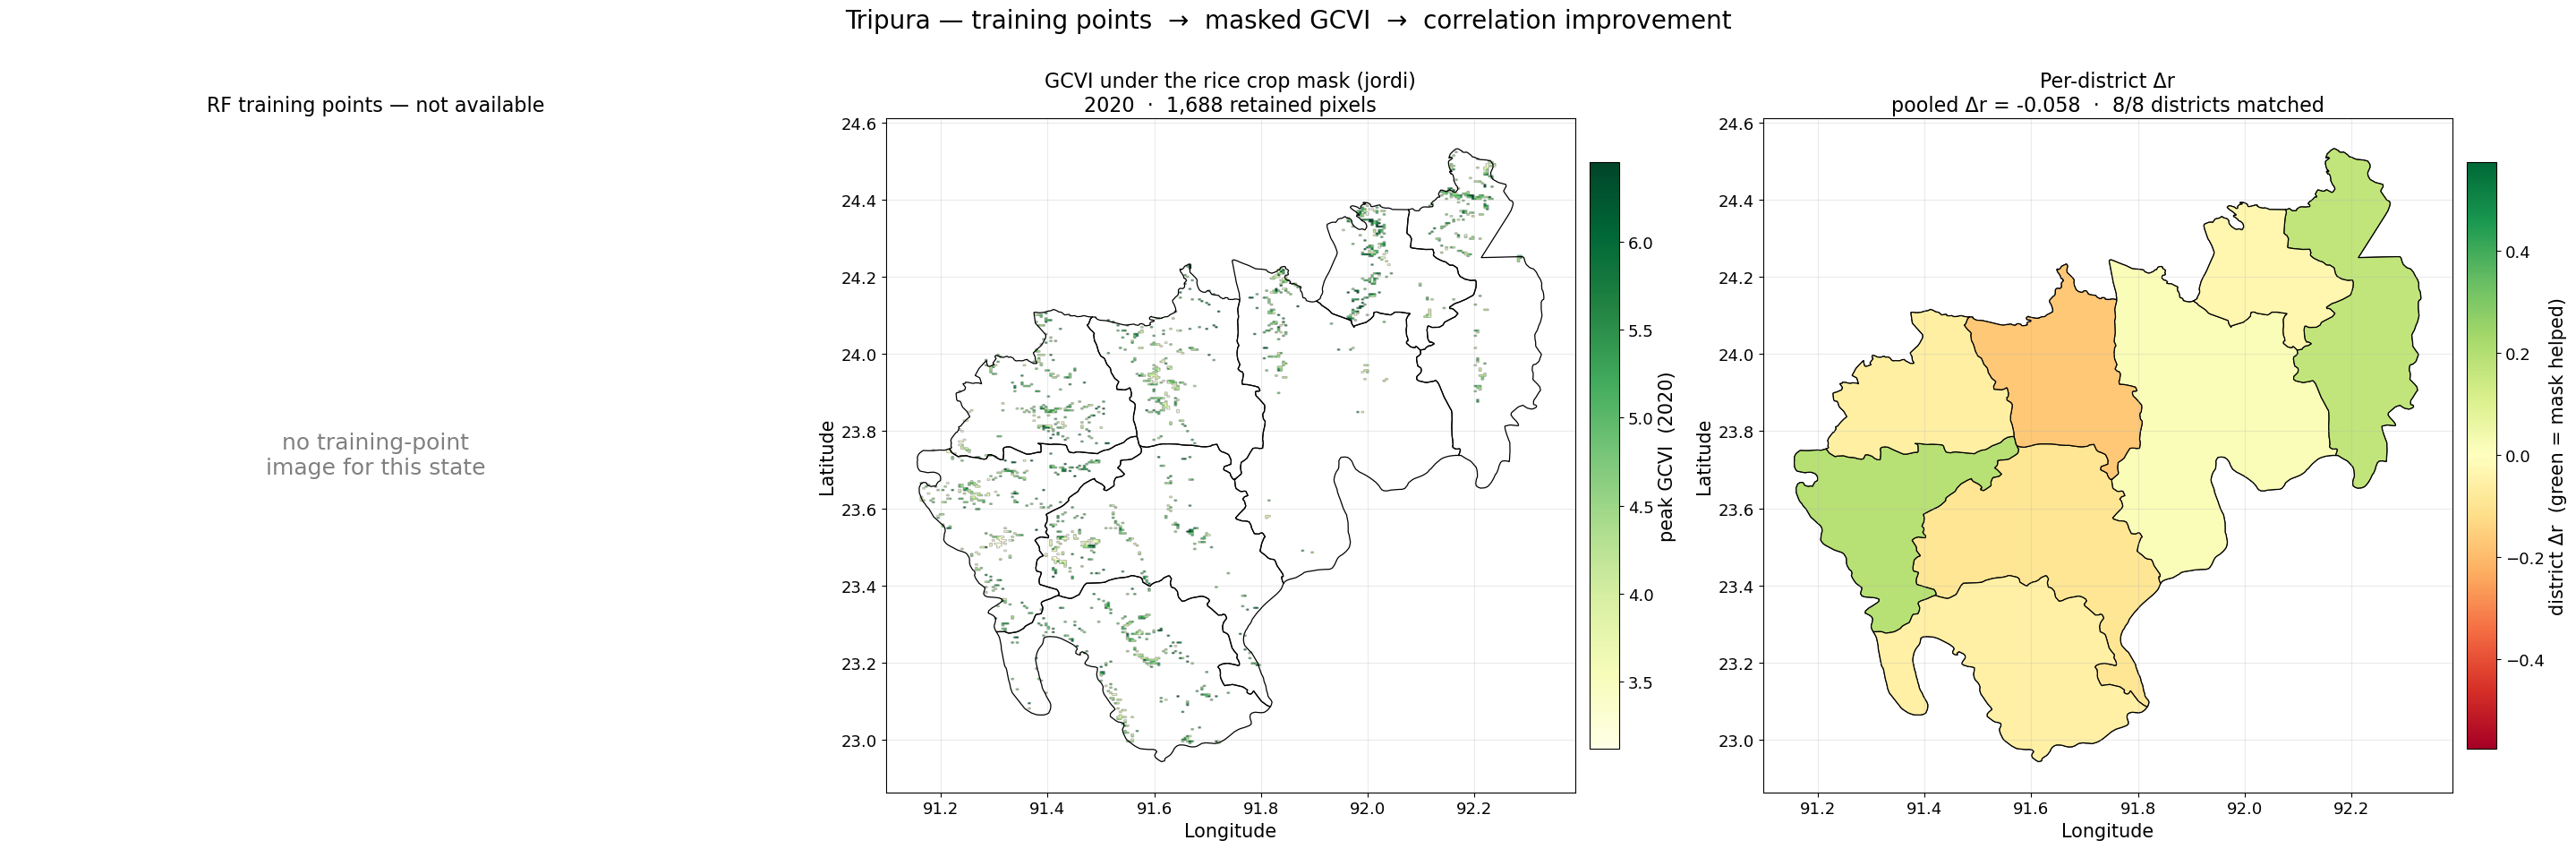

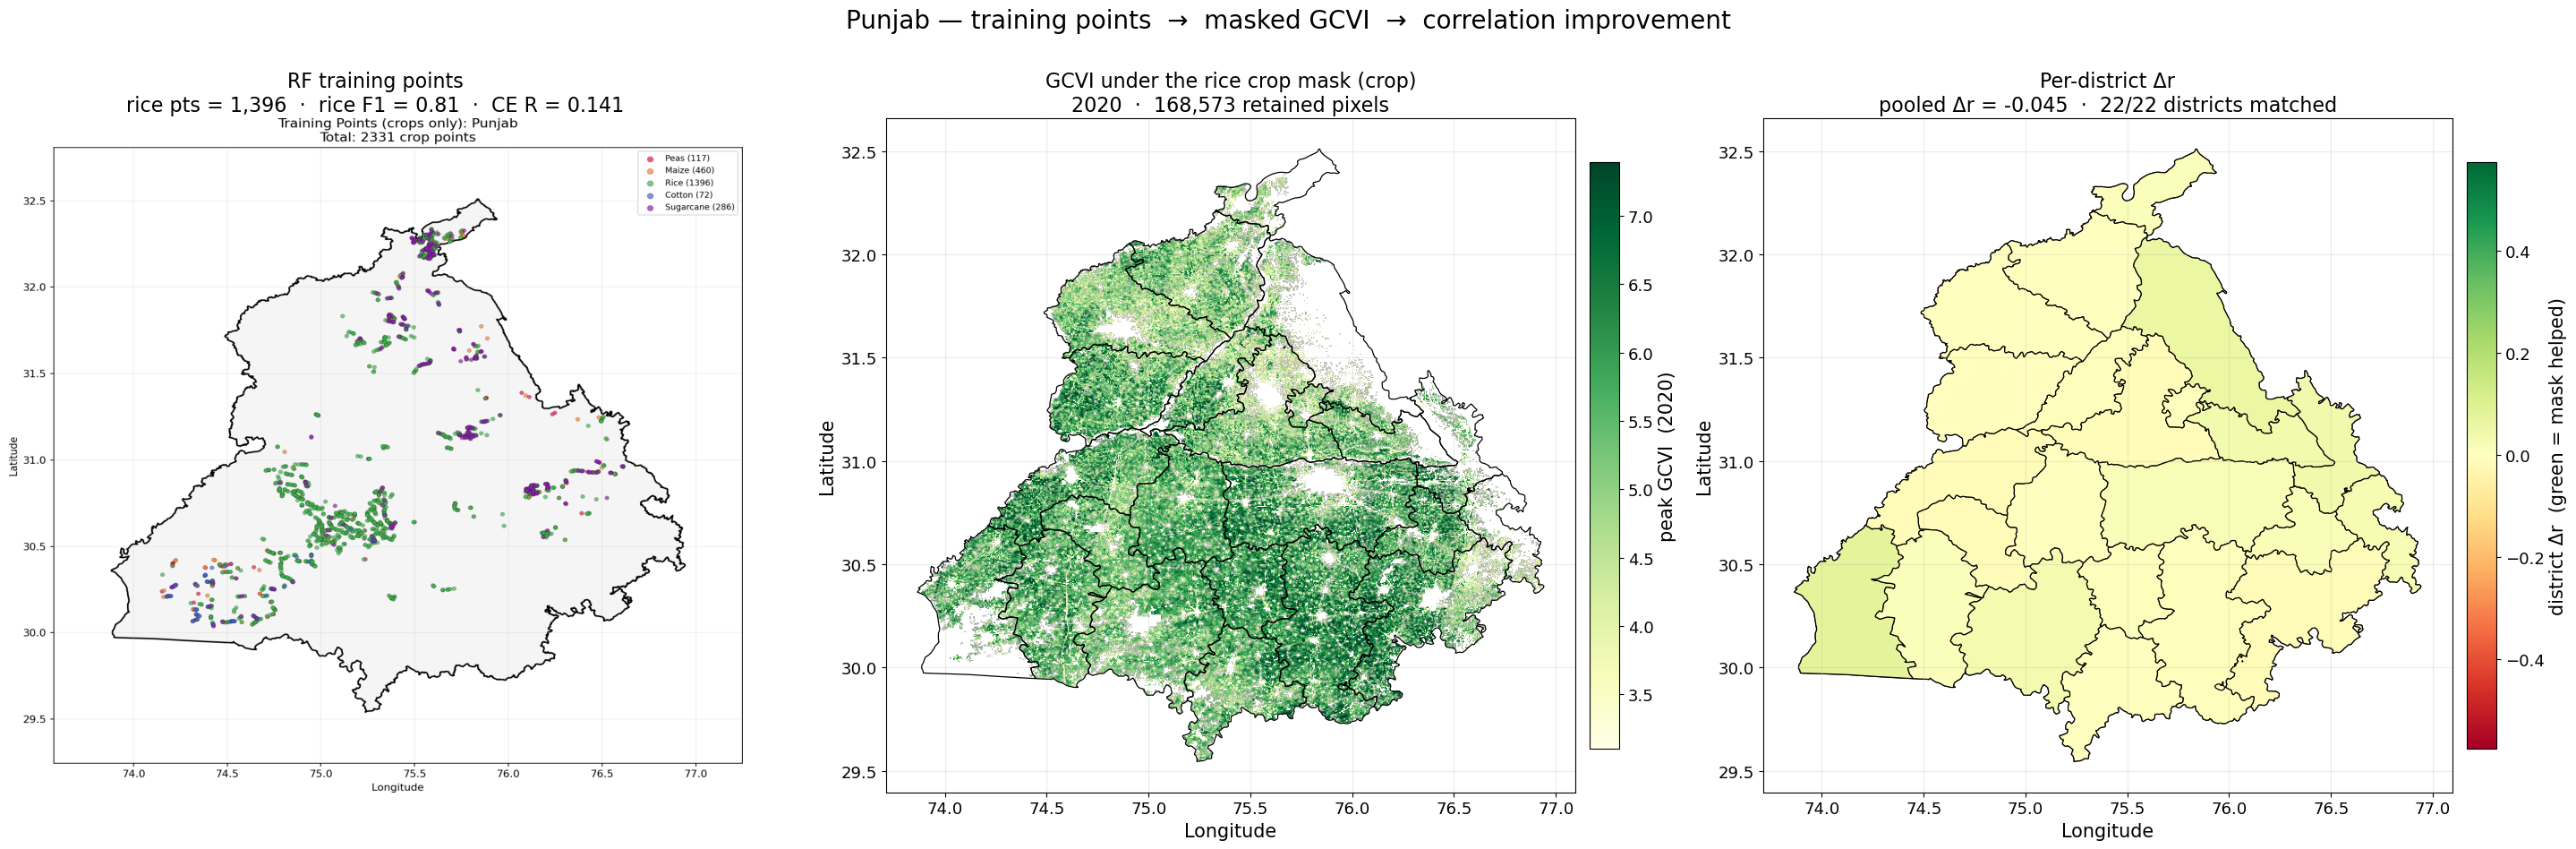

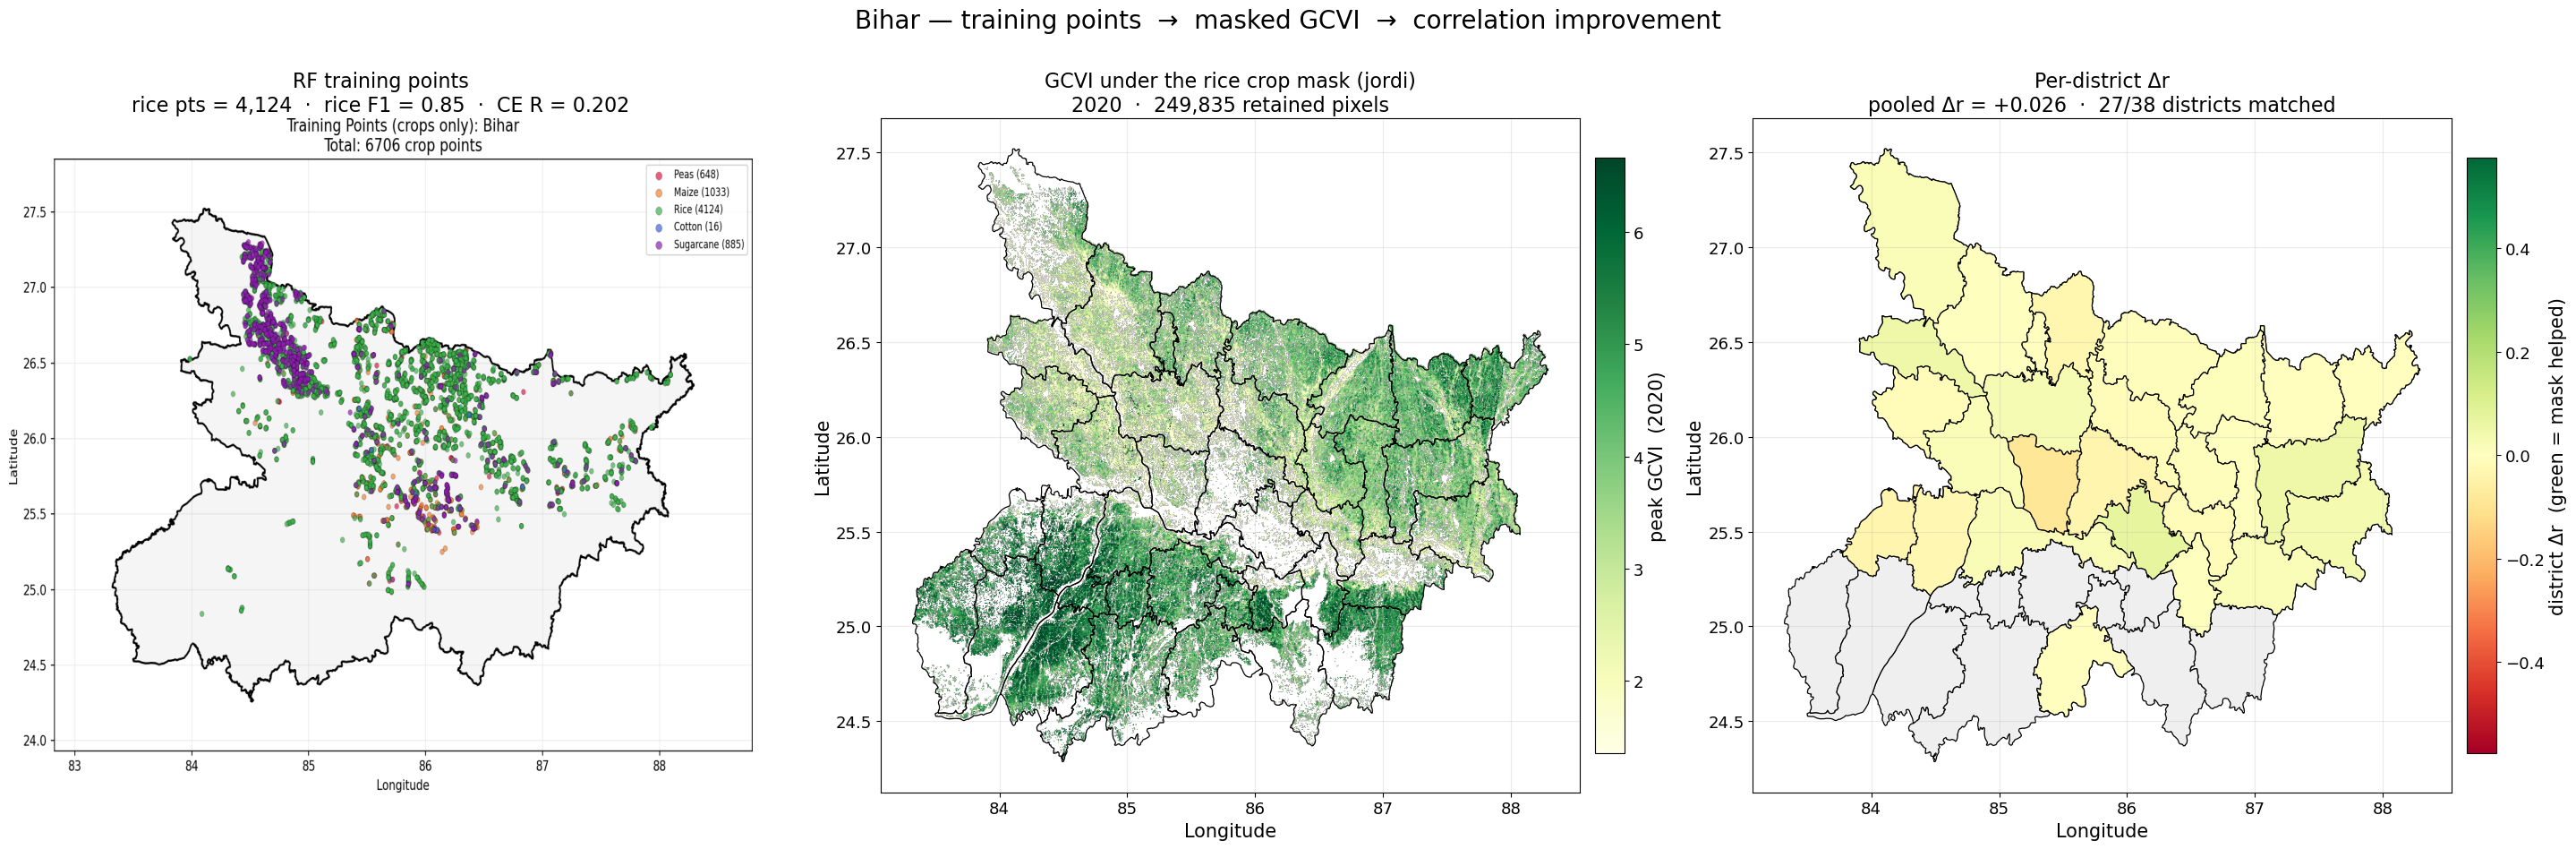

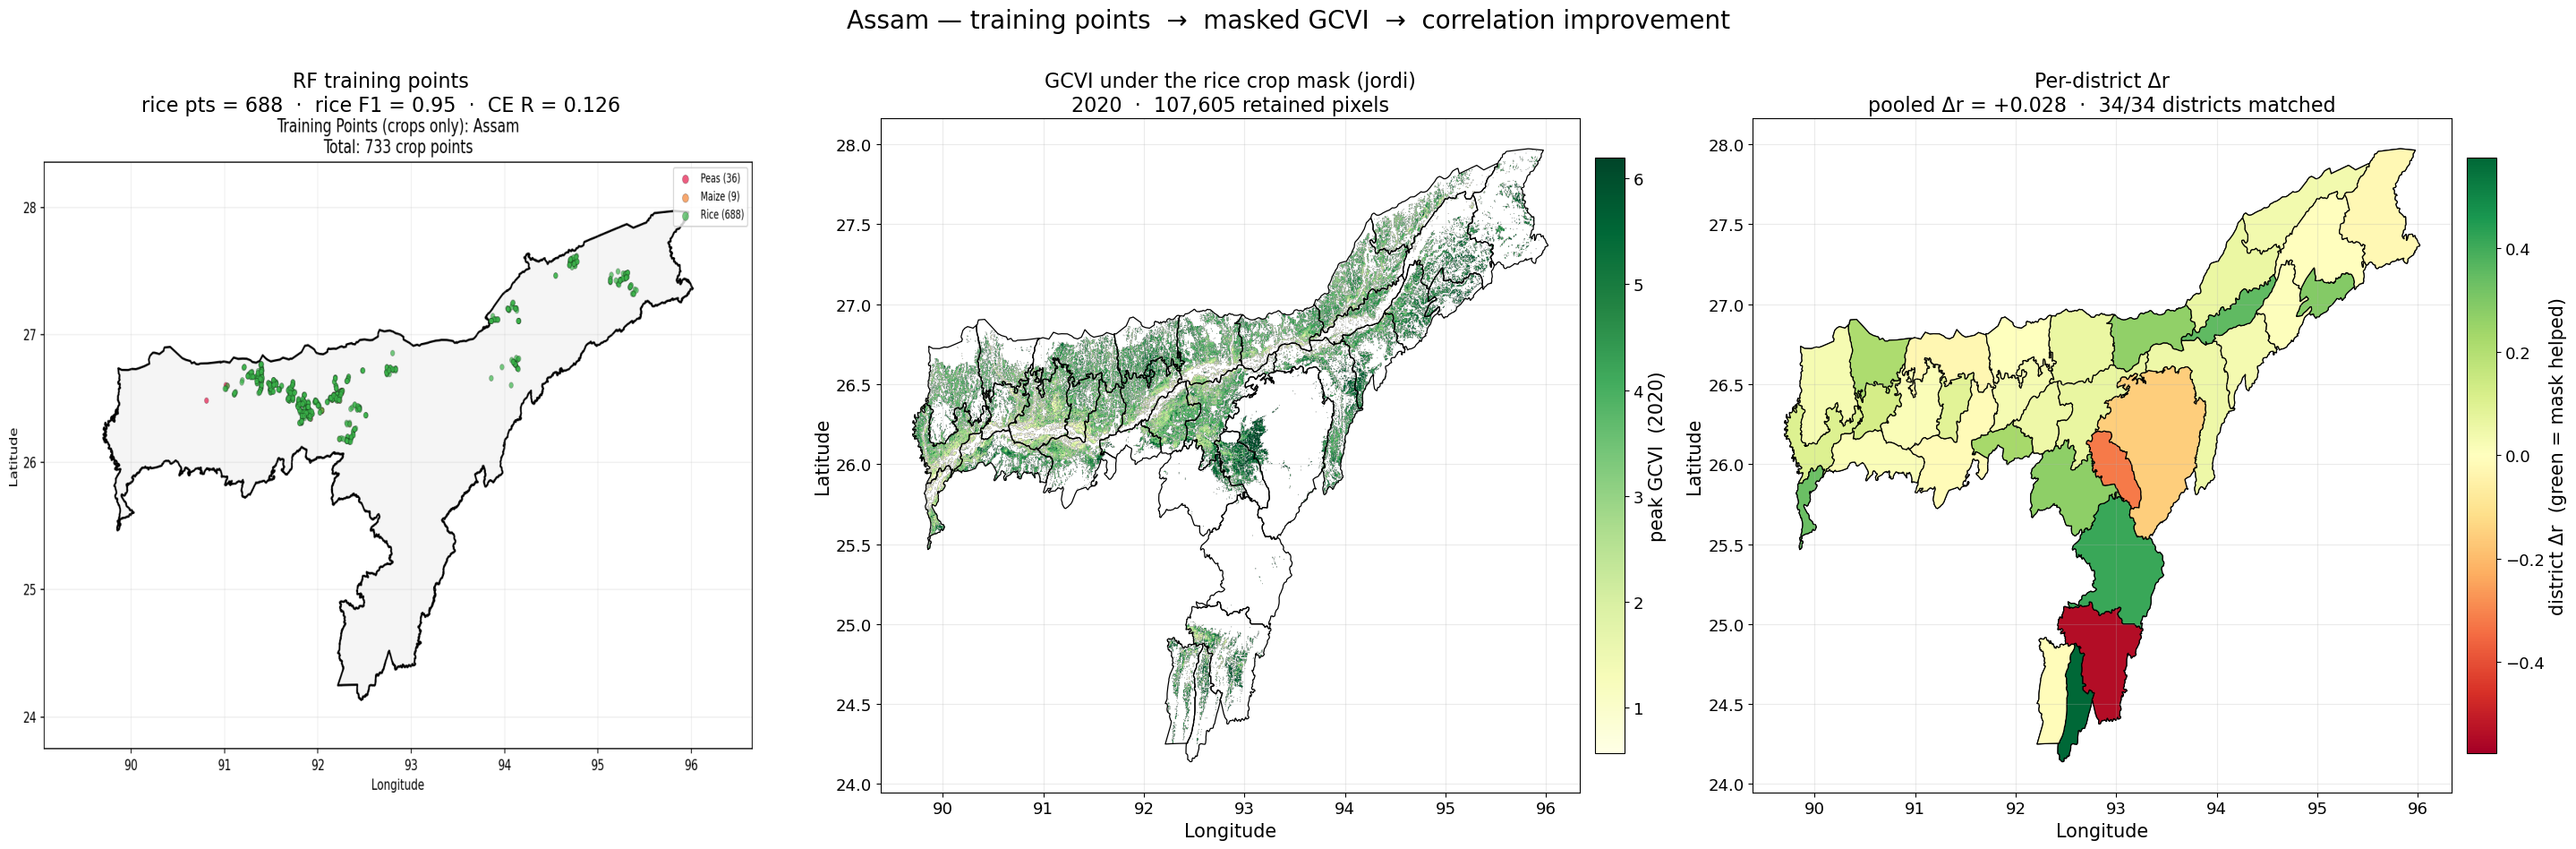

In [11]:
from matplotlib import image as mpimg
from PIL import Image, ImageChops
import rasterio as rio
import geopandas as gpd

IMG_DIR  = f'{ROOT}/data/training_points_per_state'
IMG_KEY  = {'mp': 'madhya_pradesh', 'up': 'uttar_pradesh', 'wb': 'west_bengal'}
MAP_YEAR = 2020          # year shown in the masked-GCVI panel
PAD      = 0.05


def trim_white(path):
    """Crop the PNG's white margin so the map fills its panel."""
    im = Image.open(path).convert('RGB')
    bbox = ImageChops.difference(im, Image.new('RGB', im.size, (255, 255, 255))).getbbox()
    return np.asarray(im.crop(bbox) if bbox else im)


def read_gcvi(path):
    with rio.open(path) as s:
        a = s.read(1).astype(float); nd = s.nodata; b = s.bounds
    a[np.isinf(a)] = np.nan
    if nd is not None:
        a[a == nd] = np.nan
    a[a < 0] = np.nan
    return a, [b.left, b.right, b.bottom, b.top]


def frame_like_png(ax, gdf):
    """Match the PNG framing: lon/lat axes, light grid, ~5% pad, filled panel."""
    minx, miny, maxx, maxy = gdf.total_bounds
    dx, dy = (maxx - minx) * PAD, (maxy - miny) * PAD
    ax.set_xlim(minx - dx, maxx + dx)
    ax.set_ylim(miny - dy, maxy + dy)
    ax.set_aspect('auto')
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
    ax.grid(alpha=0.25, lw=0.8)


lim = np.nanpercentile(np.abs(pd.concat([d['delta'] for d in dr.values()]).dropna()), 98)

for k in dr:
    lab  = REGION_LABELS.get(k, k)
    mask = REGION_MASKS[k][2]                     # 'crop' (Punjab/MP) or 'jordi'
    q    = qual[qual.region_key == k]
    f1   = q['f1_Rice'].values[0]          if len(q) else np.nan
    npt  = q['n_points_class_2'].values[0] if len(q) else np.nan
    ce   = q['crop_2_Rice_R'].values[0]    if len(q) else np.nan
    dl   = q['delta'].values[0]            if len(q) else np.nan

    g = load_boundary(REGIONS[k]['shp']).merge(
        d_by_state[k][['district', 'delta']], on='district', how='left')

    fig, axes = plt.subplots(1, 3, figsize=(29, 9.5))

    # ── 1. training points, whitespace trimmed ────────────────────────────
    axA = axes[0]
    f = f"{IMG_DIR}/train_points_{IMG_KEY.get(k, k)}.png"
    if os.path.exists(f):
        axA.imshow(trim_white(f), aspect='auto')
        axA.set_title(f'RF training points\n'
                      f'rice pts = {npt:,.0f}  ·  rice F1 = {f1:.2f}  ·  CE R = {ce:.3f}')
    else:
        axA.text(0.5, 0.5, 'no training-point\nimage for this state',
                 ha='center', va='center', transform=axA.transAxes,
                 fontsize=18, color='grey')
        axA.set_title('RF training points — not available')
    axA.set_xticks([]); axA.set_yticks([])
    for s in axA.spines.values():
        s.set_visible(False)

    # ── 2. GCVI masked by the rice crop mask ──────────────────────────────
    axB = axes[1]
    tif = f'{ROOT}/data/gcvi/peak_gcvi_kharif_{MAP_YEAR}_{k}_{mask}.tif'
    if os.path.exists(tif):
        arr, ext = read_gcvi(tif)
        n_px = int(np.isfinite(arr).sum())
        if n_px:
            vmin, vmax = np.nanpercentile(arr[np.isfinite(arr)], [2, 98])
            im = axB.imshow(arr, cmap='YlGn', vmin=vmin, vmax=vmax,
                            extent=ext, origin='upper')
            cbB = fig.colorbar(im, ax=axB, fraction=0.04, pad=0.02)
            cbB.set_label(f'peak GCVI  ({MAP_YEAR})')
        g.boundary.plot(ax=axB, edgecolor='black', linewidth=0.9)
        axB.set_title(f'GCVI under the rice crop mask ({mask})\n'
                      f'{MAP_YEAR}  ·  {n_px:,} retained pixels')
    else:
        axB.text(0.5, 0.5, 'TIF not found', ha='center', va='center',
                 transform=axB.transAxes, color='grey')
        axB.set_title(f'GCVI under the rice crop mask — missing')
    frame_like_png(axB, g)

    # ── 3. per-district Δr ────────────────────────────────────────────────
    axC = axes[2]
    g.plot(ax=axC, color='#efefef', edgecolor='black', linewidth=0.9)
    sub = g[g['delta'].notna()]
    if len(sub):
        sub.plot(column='delta', ax=axC, cmap='RdYlGn', vmin=-lim, vmax=lim,
                 edgecolor='black', linewidth=0.9)
    frame_like_png(axC, g)
    matched = g['delta'].notna().sum()
    axC.set_title(f'Per-district Δr\n'
                  f'pooled Δr = {dl:+.3f}  ·  {matched}/{len(g)} districts matched')
    sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=plt.Normalize(vmin=-lim, vmax=lim))
    sm.set_array([])
    cbC = fig.colorbar(sm, ax=axC, fraction=0.04, pad=0.02)
    cbC.set_label('district Δr  (green = mask helped)')

    fig.suptitle(f'{lab} — training points  →  masked GCVI  →  correlation improvement',
                 y=1.0)
    plt.tight_layout()
    plt.savefig(f'{OUT}/points_vs_delta_{k}.png', dpi=130, bbox_inches='tight')
    plt.show()

## 10. Census rice statistics — Maharashtra and Assam

Four panels per state, all framed identically: mean sown **area**, mean **yield**,
year-to-year **yield CV**, and per-district **Δr**, averaged over 2013–2024 kharif.

Area matters as much as yield here. A district reporting a high yield on ~10 000 ha of
rice contributes an unstable number to the pooled correlation, so the area panel shows
which districts the yield panel can actually be trusted in.

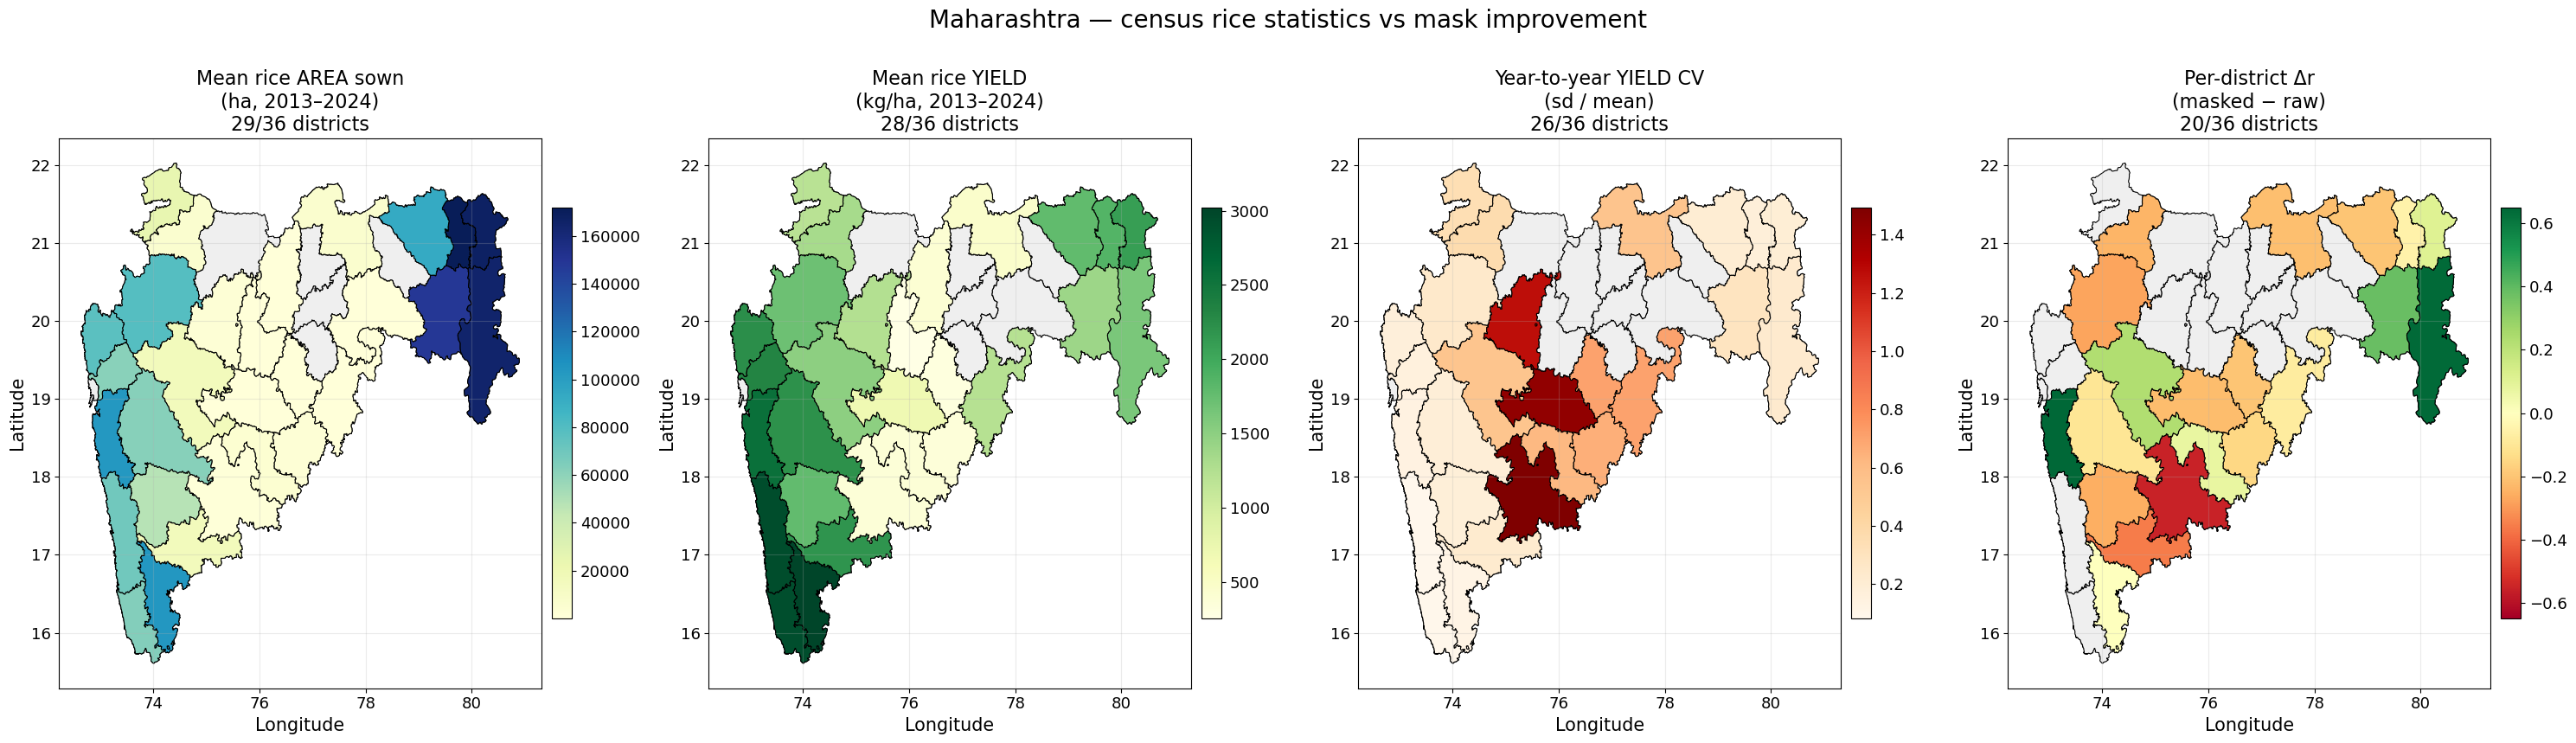


Maharashtra: 20 districts with both census rice stats and Δr
   r(rice_area_ha , district Δr) = +0.58  p=0.008 *
   r(rice_yield   , district Δr) = +0.34  p=0.140
   r(yield_cv     , district Δr) = -0.42  p=0.065


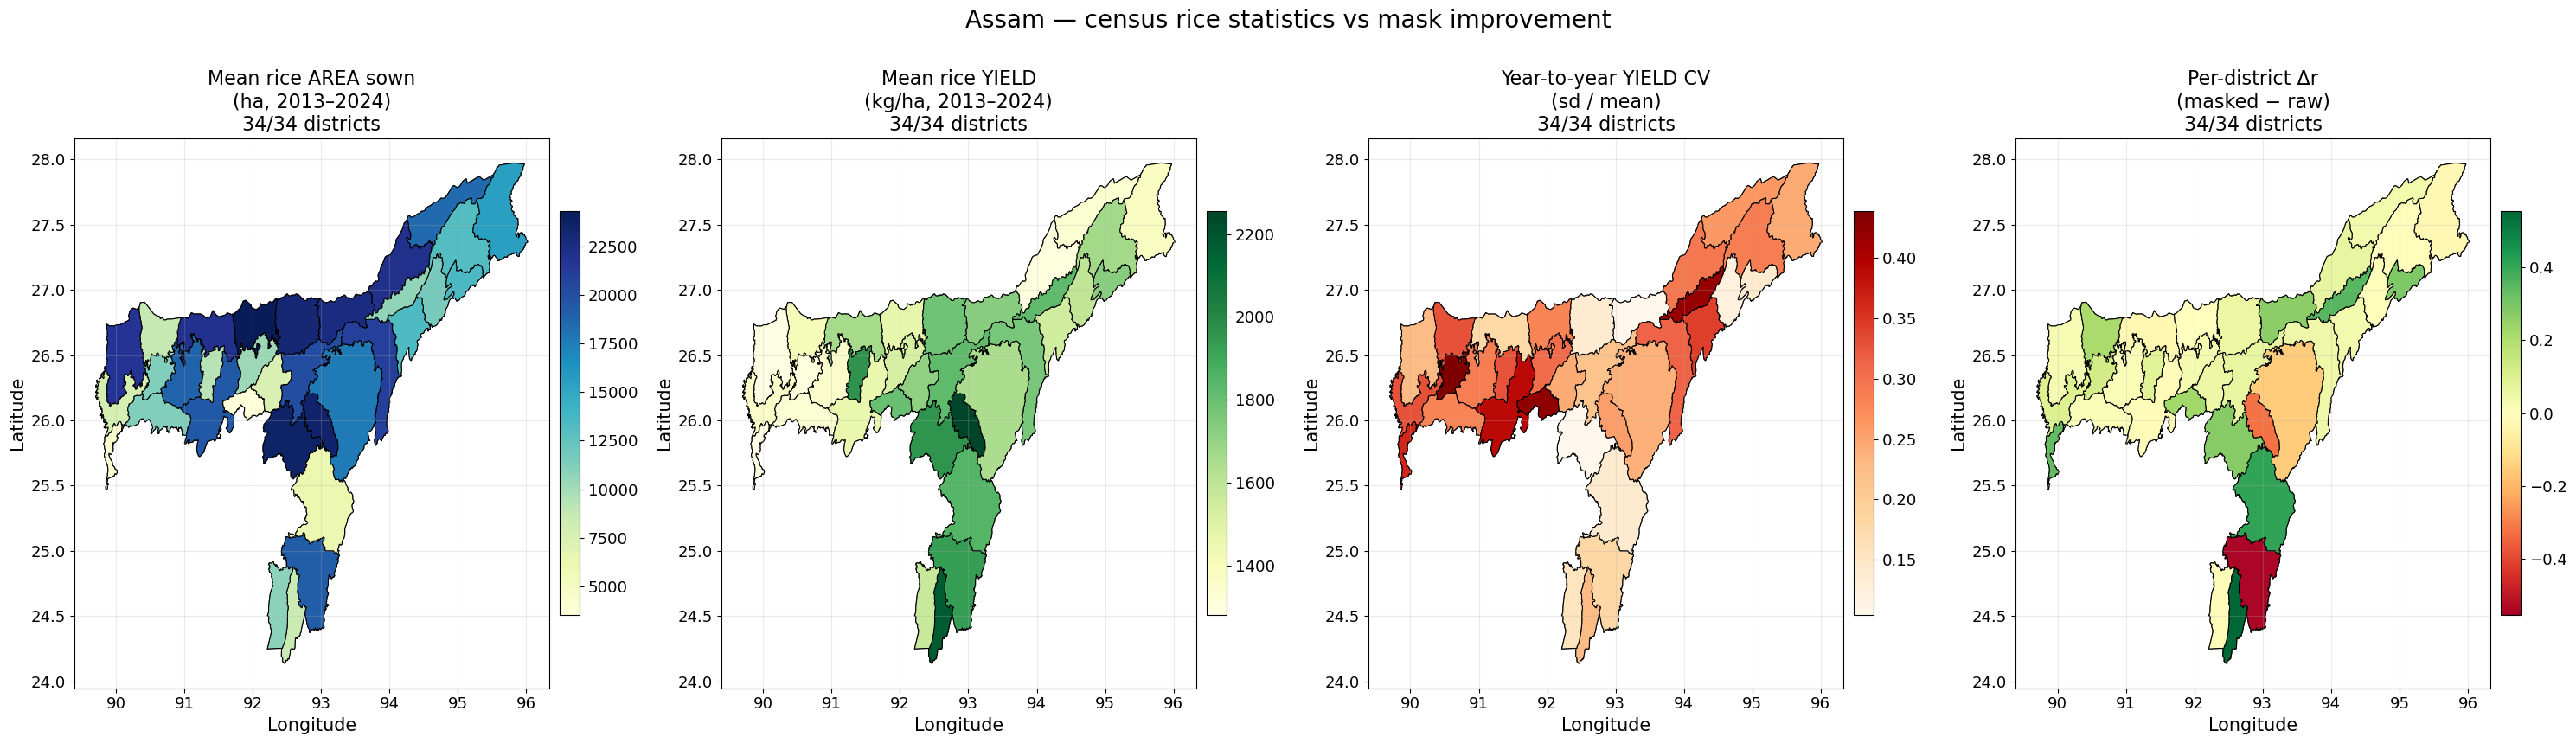


Assam: 34 districts with both census rice stats and Δr
   r(rice_area_ha , district Δr) = -0.45  p=0.008 *
   r(rice_yield   , district Δr) = +0.00  p=0.990
   r(yield_cv     , district Δr) = +0.07  p=0.690


In [12]:
import geopandas as gpd

NAME_FIXES = CFG['NAME_FIXES']
YIELD_STATES = {'maharashtra': 'Maharashtra', 'assam': 'Assam'}


def rice_census(state_name):
    """Mean rice AREA, YIELD and yield CV per district over 2013-2024 kharif."""
    rows = []
    for p in sorted(glob.glob(f'{ROOT}/data/yield/DES-District-Data-For-*.csv')):
        x = pd.read_csv(p, encoding='utf-8-sig')
        sub = x[(x['State'] == state_name) & (x['Season'] == 'Kharif') & (x['Crop'] == 'Rice')]
        for kind in ('Area', 'Yield'):
            for c in [q for q in x.columns if q.startswith(kind + '-')]:
                yr = int(re.match(rf'{kind}-(\d{{4}})', c).group(1))
                t = sub[['District', c]].copy()
                t.columns = ['district', 'val']
                t['kind'] = kind; t['year'] = yr
                rows.append(t)
    d = pd.concat(rows, ignore_index=True)
    d['val'] = pd.to_numeric(d['val'], errors='coerce')
    d['district'] = (d['district'].str.strip().str.title()
                     .str.replace(r'\s+', ' ', regex=True).replace(NAME_FIXES))
    d = d[d['val'].notna()]

    ar = d[d.kind == 'Area'].groupby('district')['val']
    yl = d[d.kind == 'Yield'].groupby('district')['val']
    out = pd.DataFrame({
        'rice_area_ha':  ar.mean(),
        'rice_yield':    yl.mean(),
        'yield_cv':      yl.std() / yl.mean(),
        'n_years_yield': yl.size(),
    }).reset_index()
    return out


for k, sname in YIELD_STATES.items():
    lab = REGION_LABELS.get(k, k)
    rc  = rice_census(sname)
    g   = (load_boundary(REGIONS[k]['shp'])
           .merge(rc, on='district', how='left')
           .merge(d_by_state[k][['district', 'delta']], on='district', how='left'))

    PANELS = [
        ('rice_area_ha',  'Mean rice AREA sown\n(ha, 2013–2024)',        'YlGnBu', None),
        ('rice_yield',    'Mean rice YIELD\n(kg/ha, 2013–2024)',         'YlGn',   None),
        ('yield_cv',      'Year-to-year YIELD CV\n(sd / mean)',          'OrRd',   None),
        ('delta',         'Per-district Δr\n(masked − raw)',             'RdYlGn', 'sym'),
    ]

    fig, axes = plt.subplots(1, 4, figsize=(30, 8.6))
    for ax, (col, title, cmap, mode) in zip(axes, PANELS):
        g.plot(ax=ax, color='#efefef', edgecolor='black', linewidth=0.8)
        sub = g[g[col].notna()]
        if len(sub):
            if mode == 'sym':
                lim = np.nanpercentile(np.abs(sub[col]), 98)
                vmin, vmax = -lim, lim
            else:
                vmin, vmax = np.nanpercentile(sub[col], [2, 98])
            sub.plot(column=col, ax=ax, cmap=cmap, vmin=vmin, vmax=vmax,
                     edgecolor='black', linewidth=0.8)
            sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
            sm.set_array([])
            fig.colorbar(sm, ax=ax, fraction=0.04, pad=0.02)
        frame_like_png(ax, g)
        ax.set_title(f'{title}\n{g[col].notna().sum()}/{len(g)} districts')

    fig.suptitle(f'{lab} — census rice statistics vs mask improvement', y=1.0)
    plt.tight_layout()
    plt.savefig(f'{OUT}/rice_census_maps_{k}.png', dpi=130, bbox_inches='tight')
    plt.show()

    # numeric summary
    v = g[['rice_area_ha', 'rice_yield', 'yield_cv', 'delta']].dropna()
    print(f"\n{lab}: {len(v)} districts with both census rice stats and Δr")
    for c in ['rice_area_ha', 'rice_yield', 'yield_cv']:
        r, p = stats.pearsonr(v[c], v['delta'])
        print(f"   r({c:<13}, district Δr) = {r:+.2f}  p={p:.3f}{' *' if p<0.05 else ''}")

## Reading the figures

- **§3 below the 1:1 line** — the mask degraded that district. If most districts sit
  below the line yet pooled Δr is positive, the pooled gain is coming from between-district
  reshuffling, not from better within-district tracking.
- **§3 red points** — districts with zero-mask years. These enter the pooled correlation
  as `(0, 0)` under the main notebook's zero-fill rule, which can move pooled r on its own.
- **§4 vertical stripes** — a single-colour column means that district's GCVI hardly
  varies across years while its yield does; GCVI carries no temporal signal there.
- **`between_district_var_share`** — fraction of yield variance that is between districts
  rather than within. High values mean the pooled r is mostly a cross-sectional ranking.
